# Forward PINN for Darcy Flow Below a Reservoir

Goal: build a **forward Physics-Informed Neural Network** for the hydraulic head field `h(x, y)`.

Important distinction:

- The Excel files are useful for **visualizing the problem** and later checking your result.
- The forward PINN loss should use **only the PDE and boundary conditions**, not the measured/generated head values.

This notebook is intentionally written as a scaffold. Some PyTorch pieces are left as `TODO` so you can implement the model yourself.


# 0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy.interpolate import griddata

import torch
import torch.nn as nn
import random


## set the same random seed for getting same reults in each running
random.seed(1)
np.random.seed(1)
torch.manual_seed(1)

## use GPU to train or mps
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# 1. Plot data

The filename pattern is:

```text
h1_h2_hd.xlsx
```

where:

- `h1` is the reservoir head,
- `h2` is the downstream catchment head,
- `hd` is the embedded wall depth.

For a forward PINN, we do **not** train on `FINIT`; here we only inspect it so we understand the geometry and have something to compare with after training.

We choose to base ourselves on the dataset
20_5_25.xlsx


(573,)


Text(0.5, 1.0, 'Scatter Plot of Water Dam Data')

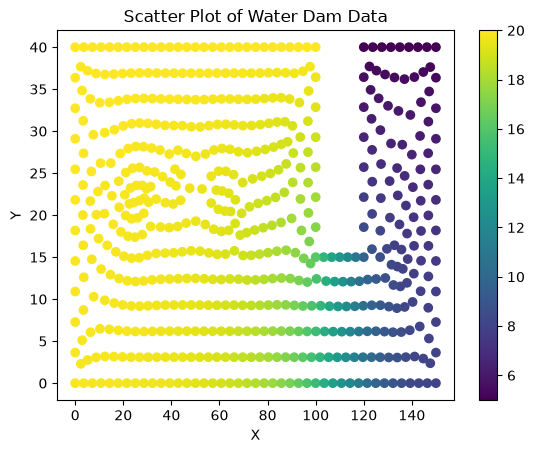

In [19]:
numericldata = pd.read_excel('../Data/heads/20_5_25.xlsx',header=0)
X_data = numericldata['X'].to_numpy()
Y_data = numericldata['Y'].to_numpy()
h_data = numericldata['FINIT'].to_numpy()

print(X_data.shape)

fig, ax = plt.subplots()
    
scatter = ax.scatter(X_data, Y_data, c=h_data, cmap='viridis')
plt.colorbar(scatter)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Scatter Plot of Water Dam Data')

### Make it into a continous map of h values

In [30]:
# Geometry of problem
h1 = 20
h2 = 5
hd = 25

L = 150

y_top = 40 # top of aquifer
y_bot = 0  # bottom of aquifer
x_left = 0  # left boundary of aquifer
x_right = L   # right boundary of aquifer

x_dleft = 100   # left boundary of dam
x_dright = 120  # right boundary of dam
y_dbot = 40 - hd    # bottom of dam

def interpolate_head(X, Y, h, 
                     grid_res=(300, 100),
                     domain_bounds=(x_left, x_right, y_bot, y_top),
                     dam_bounds=(x_dleft, x_dright, y_dbot, y_top),
                     method="linear"):
    
    x_min, x_max, y_min, y_max = domain_bounds
    num_x, num_y = grid_res

    # Generate regular 2D grid
    xi = np.linspace(x_min, x_max, num_x)
    yi = np.linspace(y_min, y_max, num_y)
    grid_x, grid_y = np.meshgrid(xi, yi)

    print(X.shape, Y.shape, h.shape)
    # Interpolate scattered points
    grid_h = griddata((X,Y), h, (grid_x, grid_y), method=method)

    # Mask out dam region
    x_dl, x_dr, y_db, y_dt = dam_bounds
    dam_mask = (grid_x >= x_dl) & (grid_x <= x_dr) & (grid_y >= y_db) & (grid_y <= y_dt)
    # Replace all h values within the dam area with nan
    grid_h[dam_mask] = np.nan

    return grid_x, grid_y, grid_h



(573,) (573,) (573,)


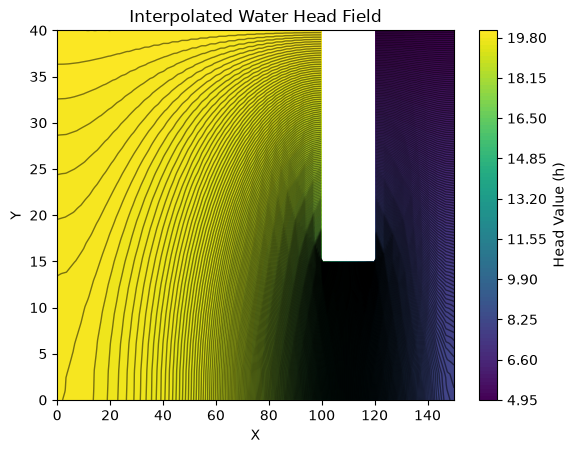

In [31]:
grid_X, grid_Y, grid_h = interpolate_head(X_data, Y_data, h_data)

fig, ax = plt.subplots()
contour = ax.contourf(grid_X, grid_Y, grid_h, levels=100, cmap="viridis")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Head Value (h)')
ax.contour(grid_X, grid_Y, grid_h, levels=600, colors='black', linewidths=1, alpha=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Interpolated Water Head Field')
plt.show()

## 3. Nondimensionalize the Governing Equation

The dimensional PDE is Laplace's equation:

$$
\Delta h = \frac{\partial^2 h}{\partial x^2} + \frac{\partial^2 h}{\partial y^2} = 0.
$$

Choose one length scale, for example the total horizontal length:

$$
L = 150\;\text{m}.
$$

Define dimensionless coordinates and head:

$$
\hat{x}=\frac{x}{L}, \qquad \hat{y}=\frac{y}{L}, \qquad
H = \frac{h-h_2}{h_1-h_2}.
$$

Then:

$$
h = h_2 + (h_1-h_2)H.
$$

Because `h2` and `(h1-h2)` are constants, the PDE becomes:

$$
\frac{\partial^2 H}{\partial \hat{x}^2} +
\frac{\partial^2 H}{\partial \hat{y}^2}=0.
$$

Boundary heads become simple:

$$
H=1 \quad \text{on the reservoir boundary},
$$

$$
H=0 \quad \text{on the downstream catchment boundary}.
$$

Impermeable boundaries satisfy no-flow, so the normal derivative is zero:

$$
\nabla H \cdot n = 0.
$$


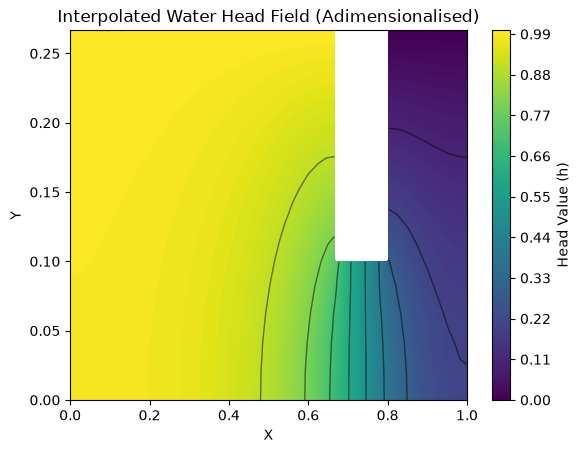

In [5]:
def to_hat_xy(xy):
    """Convert dimensional coordinates [m] to nondimensional coordinates."""
    return xy / L

def to_hat_head(h):
    return (h-h2)/(h1-h2)

def from_hat_head(H):
    """Convert nondimensional head H back to dimensional head h [m]."""
    return h2 + (h1 - h2) * H

grid_X_hat, grid_Y_hat, grid_h_hat = to_hat_xy(grid_X), to_hat_xy(grid_Y), to_hat_head(grid_h)

fig, ax = plt.subplots()
contour = ax.contourf(grid_X_hat, grid_Y_hat, grid_h_hat, levels=100, cmap="viridis")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Head Value (h)')
ax.contour(grid_X_hat, grid_Y_hat, grid_h_hat, levels=10, colors='black', linewidths=1, alpha=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Interpolated Water Head Field (Adimensionalised)')
plt.show()

# 2. Draw boundaries and sample collocation and boundary points

Collocation points and boundary condition points. We have three types of boundaries:
1. Boundaries where the value of $h$ is fixed to either $h_1$ or $h_2$
2. Boundaries where $v_x = 0$
3. Boundaries where $v_y = 0$

In [6]:
# normalise domain and dam bounds
# xmin, xmax, ymin, ymax
domain_bounds = np.array([x_left, x_right, y_bot, y_top])
dam_bounds = np.array([x_dleft, x_dright, y_dbot, y_top])

domain_bounds_norm = to_hat_xy(domain_bounds)
dam_bounds_norm = to_hat_xy(dam_bounds)

print(domain_bounds_norm)
print(dam_bounds_norm)

[0.         1.         0.         0.26666667]
[0.66666667 0.8        0.1        0.26666667]


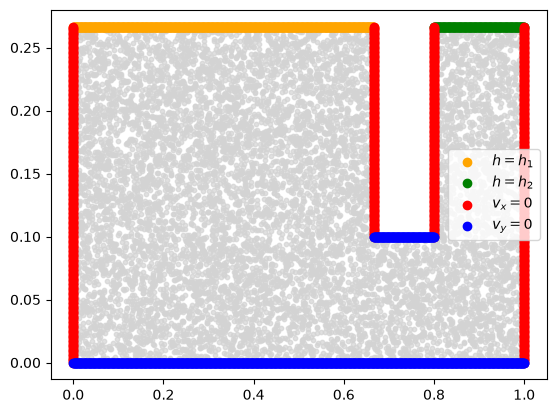

In [67]:

def sample_boundaries(n_density, domain_bounds, dam_bounds):

    x_l, x_r, y_b, y_t = domain_bounds
    x_dl, x_dr, y_db, y_dt = dam_bounds


    x1 = np.linspace(x_l, x_dl, int(n_density * (x_dl-x_l)))
    y1 = np.ones(int(n_density * (x_dl-x_l))) * y_t
    h1 = np.column_stack([x1, y1])

    x2 = np.linspace(x_dr, x_r, int(n_density*(x_r-x_dr)))
    y2 = np.ones(int(n_density*(x_r-x_dr))) * y_t
    h2 = np.column_stack([x2, y2])


    x3 = np.ones(int(n_density*(y_t-y_db))) * x_dl
    y3 = np.linspace(y_db, y_t, int(n_density*(y_t-y_db)))

    x4 = np.ones(int(n_density*(y_t-y_db))) * x_dr
    y4 = np.linspace(y_db, y_t, int(n_density*(y_t-y_db)))

    x7 = np.ones(int(n_density*(y_t))) * x_r
    y7 = np.linspace(y_b, y_t, int(n_density*(y_t)))

    x8 = np.ones(int(n_density*(y_t))) * x_l
    y8 = np.linspace(y_b, y_t, int(n_density*(y_t)))
    vx0 = np.column_stack([
        np.concatenate([x3, x4, x7, x8]),
        np.concatenate([y3, y4, y7, y8])
    ])

    y5 = np.ones(int(n_density*(x_dr-x_dl))) * y_db
    x5 = np.linspace(x_dl, x_dr, int(n_density*(x_dr-x_dl)))

    y6 = np.zeros(int(n_density*(x_r)))
    x6 = np.linspace(x_l, x_r, int(n_density*(x_r)))

    
    vy0 = np.column_stack([
        np.concatenate([x5, x6]),
        np.concatenate([y5, y6])
    ])

    return {
        "h1": h1,
        "h2": h2,
        "vx0": vx0,
        "vy0": vy0,
    }

'''def sample_interior_points(num_points, domain_bounds, dam_bounds):
    
    x_l, x_r, y_b, y_t = domain_bounds
    x_dl, x_dr, y_db, y_dt = dam_bounds

    sampled_x = []
    sampled_y = []
    
    while len(sampled_x) < num_points:
        # 1. Generate a random candidate point inside the global bounding box
        x_candidate = np.random.uniform(x_l, x_r)
        y_candidate = np.random.uniform(y_b, y_t)
        
        # 2. Check if the point falls inside the forbidden dam cutout zone
        is_inside_dam = (x_dl <= x_candidate <= x_dr) and (y_db <= y_candidate <= y_t)
        
        # 3. Only keep the point if it is NOT inside the dam
        if not is_inside_dam:
            sampled_x.append(x_candidate)
            sampled_y.append(y_candidate)
            
    return np.column_stack([np.array(sampled_x), np.array(sampled_y)])'''


import numpy as np

def sample_interior_points(num_points, domain_bounds, dam_bounds, method="random"):
    """
    Samples points within domain_bounds excluding dam_bounds.
    
    Parameters:
        num_points (int): Target number of points to sample.
        domain_bounds (tuple): (x_l, x_r, y_b, y_t)
        dam_bounds (tuple): (x_dl, x_dr, y_db, y_dt)
        method (str): 'random' for uniform Monte Carlo sampling, or 'grid' for uniform spatial grid sampling.
    """
    x_l, x_r, y_b, y_t = domain_bounds
    x_dl, x_dr, y_db, y_dt = dam_bounds

    if method == "grid":
        # Calculate domain proportions to create an aspect-ratio aware grid
        dx = x_r - x_l
        dy = y_t - y_b
        aspect_ratio = dx / dy
        
        # Estimate grid dimensions (nx * ny ~ num_points, with nx/ny ~ aspect_ratio)
        # We overshoot slightly to guarantee we hit num_points after filtering the dam region
        ny = int(np.ceil(np.sqrt(num_points / aspect_ratio))) * 2
        nx = int(np.ceil(ny * aspect_ratio)) * 2

        # Create 2D grid
        x_vals = np.linspace(x_l, x_r, nx)
        y_vals = np.linspace(y_b, y_t, ny)
        grid_x, grid_y = np.meshgrid(x_vals, y_vals)
        
        # Flatten into point arrays
        candidates_x = grid_x.ravel()
        candidates_y = grid_y.ravel()

        # Mask points falling inside the dam cutout zone
        is_inside_dam = (
            (candidates_x >= x_dl) & (candidates_x <= x_dr) & 
            (candidates_y >= y_db) & (candidates_y <= y_dt)
        )
        
        valid_points = np.column_stack([candidates_x[~is_inside_dam], candidates_y[~is_inside_dam]])
        
        # Return exact number of points asked for
        #if len(valid_points) >= num_points:
        #    # Uniformly subsample across the grid if we over-generated
        #    indices = np.linspace(0, len(valid_points) - 1, num_points, dtype=int)
        #    return valid_points[indices]
        return valid_points

    elif method == "random":
        sampled_x = []
        sampled_y = []
        
        while len(sampled_x) < num_points:
            x_candidate = np.random.uniform(x_l, x_r)
            y_candidate = np.random.uniform(y_b, y_t)
            
            # Check if inside the dam zone (matching original y_dt check)
            is_inside_dam = (x_dl <= x_candidate <= x_dr) and (y_db <= y_candidate <= y_dt)
            
            if not is_inside_dam:
                sampled_x.append(x_candidate)
                sampled_y.append(y_candidate)
                
        return np.column_stack([np.array(sampled_x), np.array(sampled_y)])

    else:
        raise ValueError(f"Unknown sampling method: {method}. Choose 'random' or 'grid'.")

    

# Sample boundary points
bc_density = 1000
bc = sample_boundaries(bc_density, domain_bounds_norm, dam_bounds_norm)


x_bc_h1, y_bc_h1 = bc['h1'][:, 0].reshape(-1, 1), bc['h1'][:, 1].reshape(-1, 1)
x_bc_h2, y_bc_h2 = bc['h2'][:, 0].reshape(-1, 1), bc['h2'][:, 1].reshape(-1, 1)
x_bc_vx0, y_bc_vx0 = bc["vx0"][:, 0].reshape(-1, 1), bc["vx0"][:, 1].reshape(-1, 1)
x_bc_vy0, y_bc_vy0 = bc["vy0"][:, 0].reshape(-1, 1), bc["vy0"][:, 1].reshape(-1, 1)



h1_color = "orange"
h2_color = "green"
vx0_color = "red"
vy0_color = "blue"


plt.scatter(x_bc_h1, y_bc_h1, color=h1_color, label="$h=h_1$")
plt.scatter(x_bc_h2, y_bc_h2, color=h2_color, label="$h=h_2$")
plt.scatter(x_bc_vx0, y_bc_vx0, color=vx0_color, label="$v_x=0$")
plt.scatter(x_bc_vy0, y_bc_vy0, color=vy0_color, label="$v_y=0$")
plt.legend()


# Sample interior points
n_points = 10000
xy_internal = sample_interior_points(n_points, domain_bounds_norm, dam_bounds_norm, method="random")
x_internal, y_internal = xy_internal[:,0].reshape(-1, 1), xy_internal[:,1].reshape(-1, 1)



plt.scatter(xy_internal[:,0], xy_internal[:,1], color='lightgray', s=10, label='Interior Sampled Points', alpha=0.7, zorder=-2)


plt.show()





# 4. Define NN model

In [14]:
class MLP(nn.Module):
    # arch = [inputs] + [hidden neurons]*number + [outputs]
    def __init__(self, arch, act):
        super(MLP, self).__init__()
        layers = []
        for i in range(len(arch) - 1):
            layers.append(nn.Linear(arch[i], arch[i + 1]))
            if i < len(arch) - 2:
                layers.append(act())
        self.model = nn.Sequential(*layers)

    def forward(self, inputs):
        out = self.model(inputs)
        return out

# 5. Define PINN Loss functions

Our model receives non-dimensional coordinates and predicts non-dimensional head:

$$
(\hat{x}, \hat{y}) \mapsto H_\theta(\hat{x}, \hat{y}).
$$

We have two types of loss: boundary condition loss and PDE loss. Each boundary type has its own loss:





In [13]:
# when head must have a specfic numerical value at boundary
def loss_bc_value(model, x, y, val):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)

    bc_real = torch.full_like(H, val, device=device)
    bc_loss = torch.mean((H - bc_real)**2)
    return bc_loss

# when one of the derivatives must vanish
# dim = 0 or 1 (x or y)
def loss_bc_grad(model, x, y, dim):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)
    
    u = x if dim==0 else y
    H_u = torch.autograd.grad(H, u,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    
    # derivative should vanish, so nonzero value is taken as loss
    bc_loss = torch.mean((H_u)**2)
    return bc_loss

# PDE loss, from LaPlace equation
def loss_pde(model, x, y):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)
    H_x = torch.autograd.grad(H, x,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_xx = torch.autograd.grad(H_x, x,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_y = torch.autograd.grad(H, y,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_yy = torch.autograd.grad(H_y, y,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]

    pde_residual = H_xx + H_yy
    return torch.mean(pde_residual**2)


# when y derivative of head must vanish



# 6. Define network architecture, build it, then train it

In [14]:
# Create neural network with tanh activation function
layers = [2] + [25]*3 + [1]
model = MLP(layers, nn.Tanh).to(device)

# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# Number of epochs
num_epochs = 500

pde_weight = 1
bc_weight_1 = 1
bc_weight_2 = 1
bc_weight_3 = 1
bc_weight_4 = 1

losses = []

# Training loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    # Compute losses
    bc_h1_loss = loss_bc_value(model, bc['h1'][:,0].reshape(-1, 1), bc['h1'][:,1].reshape(-1, 1), 1)
    bc_h2_loss = loss_bc_value(model, bc['h2'][:,0].reshape(-1, 1), bc['h2'][:,1].reshape(-1, 1), 0)
    bc_vx0_loss = loss_bc_grad(model, bc['vx0'][:,0].reshape(-1, 1), bc['vx0'][:,1].reshape(-1, 1), dim=0)
    bc_vy0_loss = loss_bc_grad(model, bc['vy0'][:,0].reshape(-1, 1), bc['vy0'][:,1].reshape(-1, 1), dim=1)

    pde_loss = loss_pde(model, x_internal, y_internal)

    # combine losses
    loss = bc_weight_1 * bc_h1_loss + bc_weight_2 * bc_h2_loss + bc_weight_3 * bc_vx0_loss + bc_weight_4 * bc_vy0_loss + pde_weight * pde_loss
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4e}, PDE Loss = {pde_loss.item():.4e}, h1 Loss = {bc_h1_loss.item():.4e}, h2 Loss {bc_h2_loss.item():.4e}, vx0 Loss {bc_vx0_loss:.4e}, vy0 Loss {bc_vy0_loss:.4e}")


epochs = np.linspace(0, num_epochs, len(losses))
plt.plot(epochs, losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")

Epoch 0: Loss = 1.1947e+00, PDE Loss = 2.6831e-04, h1 Loss = 1.1855e+00, h2 Loss 7.5468e-03, vx0 Loss 2.0542e-05, vy0 Loss 1.3108e-03
Epoch 100: Loss = 4.3354e-01, PDE Loss = 4.4652e-03, h1 Loss = 1.9091e-01, h2 Loss 1.8634e-01, vx0 Loss 5.1813e-02, vy0 Loss 1.1883e-05


KeyboardInterrupt: 

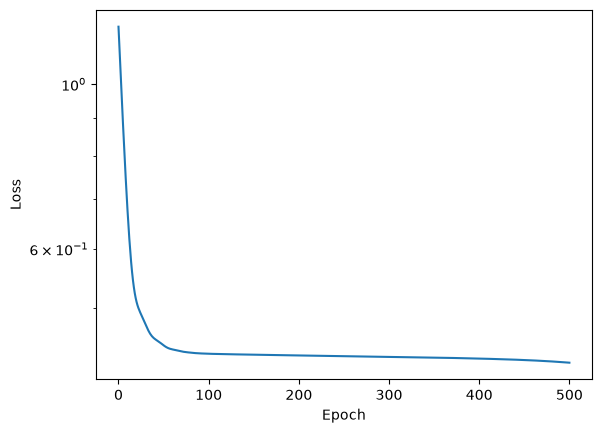

In [ ]:
plt.plot(epochs, losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.yscale("log")
plt.show()

# 7. Visualise output
not working

In [ ]:
def remove_dam(grid_x, grid_y, grid_h, dam_bounds):
    x_dl, x_dr, y_db, y_dt = dam_bounds
    dam_mask = (grid_x >= x_dl) & (grid_x <= x_dr) & (grid_y >= y_db) & (grid_y <= y_dt)
    grid_h[dam_mask] = np.nan

    return grid_h

[[0.63669366 0.6360419  0.6353893  ... 0.42305332 0.42236745 0.42168236]
 [0.6369463  0.6362929  0.6356387  ... 0.42284945 0.42216232 0.42147627]
 [0.6371993  0.6365443  0.63588846 ... 0.42264515 0.42195696 0.42126969]
 ...
 [0.66251147 0.6617116  0.6609102  ... 0.40211958 0.40131575 0.40051323]
 [0.6627883  0.66198707 0.6611843  ... 0.4018967  0.40109155 0.40028772]
 [0.6630654  0.6622627  0.6614586  ... 0.40167373 0.4008673  0.40006223]]


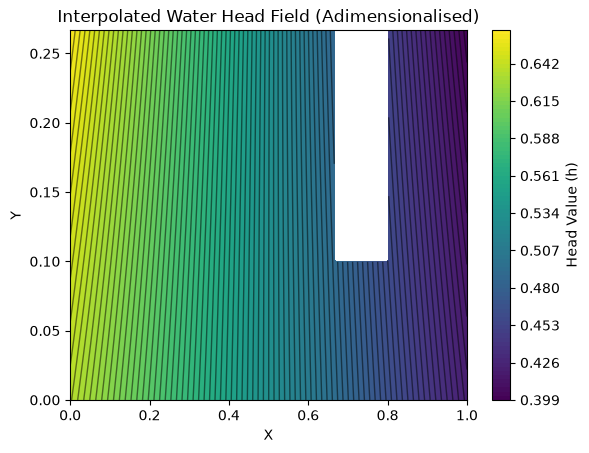

In [ ]:
Nx, Ny = 300, 100
x = np.linspace(x_left, x_right, Nx).reshape(-1, 1)
y = np.linspace(y_bot, y_top, Ny).reshape(-1, 1)

x_mesh, y_mesh = np.meshgrid(x, y)

x_mesh_hat, y_mesh_hat = to_hat_xy(x_mesh), to_hat_xy(y_mesh)
xy_hat = np.hstack((x_mesh_hat.reshape(-1, 1), y_mesh_hat.reshape(-1, 1)))
with torch.no_grad():
    H_pre = model(torch.tensor(xy_hat).float().to(device))

H_pre = H_pre.cpu().numpy().reshape(Ny, Nx)

H_pre = remove_dam(x_mesh, y_mesh, H_pre, dam_bounds=dam_bounds)

print(H_pre)

h_pre = from_hat_head(H_pre)

fig, ax = plt.subplots()
contour = ax.contourf(x_mesh_hat, y_mesh_hat, H_pre, levels=100, cmap="viridis")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Head Value (h)')
ax.contour(x_mesh_hat, y_mesh_hat, H_pre, levels=100, colors='black', linewidths=1, alpha=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Interpolated Water Head Field (Adimensionalised)')
plt.show()

# Adaptive sampling and weights

In [15]:
class Sampler:
    def __init__(self, h1, h2, domain_bounds, dam_bounds):
        self.h1 = h1
        self.h2 = h2
        self.domain_bounds = domain_bounds
        self.dam_bounds = dam_bounds

    def normalise_xy(self, xy):
        # x length of domain
        L = self.domain_bounds[1] - self.domain_bounds[0]
        return xy / L

    def inv_normalise_xy(self, xy):
        # x length of domain
        L = self.domain_bounds[1] - self.domain_bounds[0]
        return L*xy
    
    def normalise_h(self, h):
        return (h - self.h2)/(self.h1-self.h2)

    def inv_normalise_h(self, h):
        return self.h2 + (self.h1 - self.h2) * h
        


    def sample(self, num_dom, density_bc, normalise=True):

        dom_points = self.sample_domain(num_dom, normalise)
        bc_points = self.sample_boundaries(density_bc, normalise)

        return dom_points, bc_points

    def sample_boundaries(self, n_density, normalise):
        dom_bounds = to_hat_xy(self.domain_bounds) if normalise else self.domain_bounds
        dam_bounds = to_hat_head(self.dam_bounds) if normalise else self.dam_bounds

        bc_points = sample_boundaries(n_density, domain_bounds=dom_bounds, dam_bounds=dam_bounds)
        return bc_points
    
    def sample_domain(self, num_dom, normalise):
        dom_bounds = to_hat_xy(self.domain_bounds) if normalise else self.domain_bounds
        dam_bounds = to_hat_head(self.dam_bounds) if normalise else self.dam_bounds

        domain_points = sample_interior_points(num_dom, dom_bounds, dam_bounds)

        return domain_points

In [89]:
class PINN_trainer(nn.Module):
    def __init__(
            self, 
            model, 
            loss_fn=torch.nn.MSELoss(), 
            device='cpu'):
        super(PINN_trainer, self).__init__()
        self.model = model.to(device)
        self.adaptive_points = None  # Initialize adaptive points

        self.loss_fn = loss_fn
        self.device = device

    def net_forward(self, x, y):
        x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
        y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

        inputs = torch.cat((x, y), dim=1)
        h = self.model(inputs)
        return h
    
    def bc_value_residual(self, x, y, val):
        x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
        y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

        input = torch.cat((x,y), dim=1)
        h = self.model(input)

        bc_real = torch.full_like(h, val, device=self.device)
        bc_resi = bc_real - h

        return bc_resi

    # when velocity component must vanish
    def bc_velocity_residual(self, x, y, component="x"):
        x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
        y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

        input = torch.cat((x,y), dim=1)
        h = self.model(input)
        
        u = x if component=='x' else y
        h_u = torch.autograd.grad(h, u,
                                grad_outputs=torch.ones_like(h),
                                create_graph=True)[0]
        
        return h_u

    def pde_residual(self, x, y):
        x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
        y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

        input = torch.cat((x,y), dim=1).requires_grad_()
        h = self.model(input)
        h_x = torch.autograd.grad(h, x,
                                grad_outputs=torch.ones_like(h),
                                create_graph=True)[0]
        h_xx = torch.autograd.grad(h_x, x,
                                grad_outputs=torch.ones_like(h),
                                create_graph=True)[0]
        h_y = torch.autograd.grad(h, y,
                                grad_outputs=torch.ones_like(h),
                                create_graph=True)[0]
        h_yy = torch.autograd.grad(h_y, y,
                                grad_outputs=torch.ones_like(h),
                                create_graph=True)[0]

        return h_xx + h_yy
    
    # what is num_points
    def adaptive_sampling(self, num_points, base_grid_points, method):
        base_grid_x = base_grid_points[:, 0:1].to(self.device).requires_grad_(True)
        base_grid_y = base_grid_points[:, 1:2].to(self.device).requires_grad_(True)
        
        # what does this do?
        self.eval()

        if method == "gar":
            h = self.net_forward(base_grid_x, base_grid_y)

            # calculate gradients to see the steepest prediction points
            h_x = torch.autograd.grad(h, base_grid_x, torch.ones_like(h), create_graph=True, retain_graph=True)[0]
            h_y = torch.autograd.grad(h, base_grid_y, torch.ones_like(h), create_graph=True, retain_graph=True)[0]

            _, idx_h_x = torch.topk(h_x.squeeze().abs(), num_points)
            _, idx_h_y = torch.topk(h_y.squeeze().abs(), num_points)

            # idk what this does
            idx = torch.cat((idx_h_x, idx_h_y), dim=0)
            idx = torch.unique(idx)

        if method == "rar":
            pde_residual = self.pde_residual(base_grid_x, base_grid_y)
            _, idx = torch.topk(pde_residual.squeeze().abs(), num_points)


        adaptive_points = base_grid_points[idx, :]
        return adaptive_points

    def calc_jacobian(self, output):
        output = output.view(-1)
        size = output.shape[0]
        # Compute batched gradients w.r.t. all parameters except last layer
        gradients = torch.autograd.grad(output, list(self.parameters())[:-1], grad_outputs=torch.eye(size).to(self.device), is_grads_batched=True, retain_graph=True)

        # Concatenate  gradients into Jacobian matrix
        jacobian = torch.cat([grad.flatten().view(size, -1) for grad in gradients], dim=1)
        return jacobian
    
    def calc_ntk(self, jacobian, computation_type='trace'):
        """Compute Neural Tangent Kernel metrics from Jacobian matrix."""

        # Define computation methods using Einstein summation
        ntk_operations = {
            'full': lambda jac: torch.einsum('Na,Ma->NM', jac, jac),  # Full NTK matrix
            'diag': lambda jac: torch.einsum('Na,Na->N', jac, jac),   # Diagonal elements
            'trace': lambda jac: torch.einsum('Na,Na->', jac, jac)    # Trace (scalar)
        }

        if computation_type not in ntk_operations:
            raise ValueError(f'Metric "{computation_type}" not supported. '
                            f'Choose from: {list(ntk_operations.keys())}')

        return ntk_operations[computation_type](jacobian)

    
    def calculate_adaptive_weights(self, loss_residuals, sampling_strategy, batch_size, return_info=False):
        """Compute NTK-based adaptive weights for loss terms."""
        traces, jacs = [], []

        for res in loss_residuals:
            n = len(res)
            if sampling_strategy == "random": # random-batch technique
                idx = np.random.randint(0, n, batch_size) if batch_size < n else slice(None)
                jac = self.calc_jacobian(res[idx])
                norm = batch_size if batch_size < n else n
            elif sampling_strategy == "topres":  # compute the weight using the points with top residuals
                idx = slice(0, batch_size) if batch_size < n else slice(None)
                jac = self.calc_jacobian(res[idx])
                norm = batch_size if batch_size < n else n
            elif sampling_strategy == "mini": # compute the weight using mini-batch technique
                trace = 0
                for i in range(0, n, batch_size):
                    jac = self.calc_jacobian(res[i:i + batch_size])
                    trace += self.calc_ntk(jac, computation_type='trace').item()
                traces.append(trace / n)
                if return_info:
                    jacs.append(jac)
                continue
            elif sampling_strategy == "full":
                jac = self.calc_jacobian(res)
                norm = n
            else:
                raise ValueError(f"Unknown sampling strategy: {sampling_strategy}. Must be one of 'random', 'topres', 'mini', or 'full'.")

            trace = self.calc_ntk(jac, computation_type='trace').item()
            traces.append(trace / norm)
            if return_info:
                jacs.append(jac)

        traces = np.array(traces)
        weights = traces.sum() / traces
        return (weights, jacs) if return_info else weights


    def predict(self, x, y):
        self.model.eval()
        with torch.no_grad():
            #x = x.to(self.device)
            #y = y.to(self.device)
            return self.net_forward(x, y).cpu().numpy()


    def evaluate(self, real_X, real_Y, real_h, domain_bounds, dam_bounds, grid_res=(300, 100), vbounds=(0., 1.)):
        self.model.eval()

        xmin, xmax, ymin, ymax = domain_bounds
        x_dl, x_dr, y_db, y_dt = dam_bounds

        # Prepare testing grid
        x_test = torch.linspace(xmin, xmax, grid_res[0]).reshape(-1, 1).to(self.device)
        y_test = torch.linspace(ymin, ymax, grid_res[1]).reshape(-1, 1).to(self.device)
        x_grid_display, y_grid_display = torch.meshgrid(x_test.squeeze(), y_test.squeeze(), indexing='ij')
        x_grid_display, y_grid_display = x_grid_display.cpu(), y_grid_display.cpu()
        #x_grid_flat = x_grid.reshape(-1, 1)
        #y_grid_flat = y_grid.reshape(-1, 1)

        xy = sample_interior_points(10000, domain_bounds, dam_bounds, method="grid")
        #x_grid, y_grid = torch.meshgrid(x_test.squeeze(), y_test.squeeze(), indexing='ij')
        x_grid_flat, y_grid_flat = xy[:,0].reshape(-1, 1), xy[:,1].reshape(-1, 1)

        # Predict using trained model
        h_pred = self.predict(x_grid_flat, y_grid_flat)#.reshape(grid_res[0], grid_res[1])
        print(x_grid_flat[:,0])
        print(x_grid_flat.shape, y_grid_flat.shape, h_pred.shape)
        h_pred_display = griddata((x_grid_flat[:,0], y_grid_flat[:,0]), h_pred[:,0], (x_grid_display, y_grid_display), method="linear")


        # Interpolate real points to form colormap
        #x_grid, y_grid = x_grid.cpu().numpy(), y_grid.cpu().numpy()
        h_real_display = griddata((real_X, real_Y), real_h, (x_grid_display, y_grid_display), method='linear')

        # Mask out dam region
        dam_mask = (x_grid_display >= x_dl) & (x_grid_display <= x_dr) & (y_grid_display >= y_db) #& (y_grid <= y_dt) # some datapoints at top part of dam are left, probably floating point error

        h_pred_display[dam_mask] = np.nan
        h_real_display[dam_mask] = np.nan
        #diff[dam_mask] = np.nan


        # Calculate errors
        diff = np.abs(h_pred_display - h_real_display)
        print(f"{diff.shape = }, {h_real_display.shape =}")
        #Calculate L2 normalized relative error
        #print(f"{diff = }")
        L2_relative_error = np.linalg.norm(diff[~np.isnan(diff)]) / np.linalg.norm(h_real_display[~np.isnan(diff)])
        print(f'L2 Normalized Relative Error: {L2_relative_error:.4f}')

        # Calculate accuracy as 1 - normalized RMSE
        acc = 1 - np.sqrt(np.mean(diff[~np.isnan(diff)] ** 2))

        



        


        fig, axes = plt.subplots(1, 3, figsize=(20, 4))
        axes = axes.flatten()

        axes[0].imshow(h_pred_display.T, aspect='auto', origin='lower', extent=[xmin, xmax, ymin, ymax], cmap="viridis", vmin=vbounds[0], vmax=vbounds[1])
        axes[0].set_title(f"PINN Prediction")

        axes[1].imshow(h_real_display.T, aspect='auto', origin='lower', extent=[xmin, xmax, ymin, ymax], cmap="viridis", vmin=vbounds[0], vmax=vbounds[1])
        axes[1].set_title("Reference Solution")

        axes[2].imshow(diff.T, aspect='auto', origin='lower', extent=[xmin, xmax, ymin, ymax], cmap="binary")
        axes[2].set_title(f"Absolute Error, Accuracy: {acc:.3f}")

        plt.colorbar(axes[0].images[0], ax=axes[0])
        plt.colorbar(axes[1].images[0], ax=axes[1])
        plt.colorbar(axes[2].images[0], ax=axes[2])
        plt.tight_layout()
        plt.show()

        return fig, axes, acc


    # saves as a .pt file, PyTorch's native format for saving and loading model parameters    
    def save_weights(self, save_path):
        torch.save(self.model.state_dict(), save_path)

    '''def evaluate(self, real_X, real_Y, real_h, domain_bounds, dam_bounds, grid_res=(300, 100), vbounds=(0., 1.)):
        self.model.eval()

        xmin, xmax, ymin, ymax = domain_bounds
        x_dl, x_dr, y_db, y_dt = dam_bounds

        # Prepare testing grid
        x_test = torch.linspace(xmin, xmax, grid_res[0]).reshape(-1, 1).to(self.device)
        y_test = torch.linspace(ymin, ymax, grid_res[1]).reshape(-1, 1).to(self.device)
        x_grid, y_grid = torch.meshgrid(x_test.squeeze(), y_test.squeeze(), indexing='ij')
        x_grid_flat = x_grid.reshape(-1, 1)
        y_grid_flat = y_grid.reshape(-1, 1)
        # Predict using trained model
        h_pred = self.predict(x_grid_flat, y_grid_flat).reshape(grid_res[0], grid_res[1])

        # Interpolate real points to form colormap
        x_grid, y_grid = x_grid.cpu().numpy(), y_grid.cpu().numpy()
        h_real = griddata((real_X, real_Y), real_h, (x_grid, y_grid), method='linear')

        # Calculate errors
        diff = np.abs(h_pred - h_real)
        #Calculate L2 normalized relative error
        #print(f"{diff = }")
        L2_relative_error = np.linalg.norm(diff[~np.isnan(diff)]) / np.linalg.norm(h_real[~np.isnan(diff)])
        print(f'L2 Normalized Relative Error: {L2_relative_error:.4f}')

        # Calculate accuracy as 1 - normalized RMSE
        acc = 1 - np.sqrt(np.mean(diff[~np.isnan(diff)] ** 2))

        



        # Mask out dam region
        dam_mask = (x_grid >= x_dl) & (x_grid <= x_dr) & (y_grid >= y_db) & (y_grid <= y_dt)

        h_pred[dam_mask] = np.nan
        h_real[dam_mask] = np.nan
        diff[dam_mask] = np.nan


        fig, axes = plt.subplots(1, 3, figsize=(20, 4))
        axes = axes.flatten()

        axes[0].imshow(h_pred.T, aspect='auto', origin='lower', extent=[xmin, xmax, ymin, ymax], cmap="viridis", vmin=vbounds[0], vmax=vbounds[1])
        axes[0].set_title(f"PINN Prediction")

        axes[1].imshow(h_real.T, aspect='auto', origin='lower', extent=[xmin, xmax, ymin, ymax], cmap="viridis", vmin=vbounds[0], vmax=vbounds[1])
        axes[1].set_title("Reference Solution")

        axes[2].imshow(diff.T, aspect='auto', origin='lower', extent=[xmin, xmax, ymin, ymax], cmap="binary")
        axes[2].set_title(f"Absolute Error, Accuracy: {acc:.3f}")

        plt.colorbar(axes[0].images[0], ax=axes[0])
        plt.colorbar(axes[1].images[0], ax=axes[1])
        plt.colorbar(axes[2].images[0], ax=axes[2])
        plt.tight_layout()
        plt.show()
        '''









[array([0.        , 1.        , 0.        , 0.26666667]), array([0.66666667, 0.8       , 0.1       , 0.26666667])]


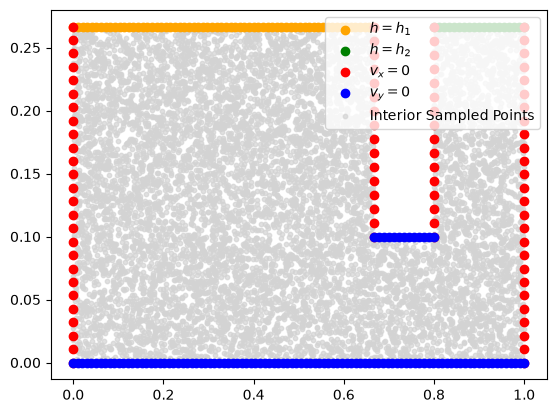

(573,) (573,) (573,)


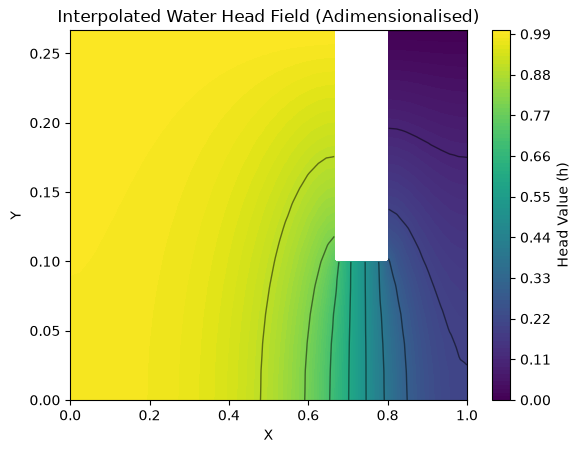

In [90]:
BC_DENSITY = 100
DOM_PTS = 10000
NORMALISE = True

if NORMALISE:
    H1, H2 = 1, 0
    bounds = [domain_bounds_norm, dam_bounds_norm]
    X_real, Y_real, h_real = to_hat_xy(X_data), to_hat_xy(Y_data), to_hat_head(h_data)
else:
    H1, H2 = 20, 5
    bounds = [domain_bounds, dam_bounds]
    X_real, Y_real, h_real = X_data, Y_data, h_data

print(bounds)

# Sample boundary points
bc = sample_boundaries(BC_DENSITY, bounds[0], bounds[1])
x_h1, y_h1 = bc['h1'][:,0].reshape(-1, 1), bc['h1'][:,1].reshape(-1, 1)
x_h2, y_h2 = bc['h2'][:,0].reshape(-1, 1), bc['h2'][:,1].reshape(-1, 1)
x_vx0, y_vx0 = bc['vx0'][:,0].reshape(-1, 1), bc['vx0'][:,1].reshape(-1, 1)
x_vy0, y_vy0 = bc['vy0'][:,0].reshape(-1, 1), bc['vy0'][:,1].reshape(-1, 1)


# Sample interior points
xy_internal = sample_interior_points(DOM_PTS, bounds[0], bounds[1])
x_internal, y_internal = xy_internal[:,0].reshape(-1, 1), xy_internal[:,1].reshape(-1, 1)

h1_color = "orange"
h2_color = "green"
vx0_color = "red"
vy0_color = "blue"


plt.scatter(x_h1, y_h1, color=h1_color, label="$h=h_1$")
plt.scatter(x_h2, y_h2, color=h2_color, label="$h=h_2$")
plt.scatter(x_vx0, y_vx0, color=vx0_color, label="$v_x=0$")
plt.scatter(x_vy0, y_vy0, color=vy0_color, label="$v_y=0$")


plt.scatter(x_internal, y_internal, color='lightgray', s=10, label='Interior Sampled Points', alpha=0.7, zorder=-2)

plt.legend()

plt.show()


gX_real, gY_real, gh_real = interpolate_head(X_real, Y_real, h_real, domain_bounds=bounds[0], dam_bounds=bounds[1])
fig, ax = plt.subplots()
contour = ax.contourf(gX_real, gY_real, gh_real, levels=100, cmap="viridis", vmin=H2, vmax=H1)
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Head Value (h)')
ax.contour(gX_real, gY_real, gh_real, levels=10, colors='black', linewidths=1, alpha=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Interpolated Water Head Field (Adimensionalised)')
plt.show()

In [94]:
# Set random seed for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.6796


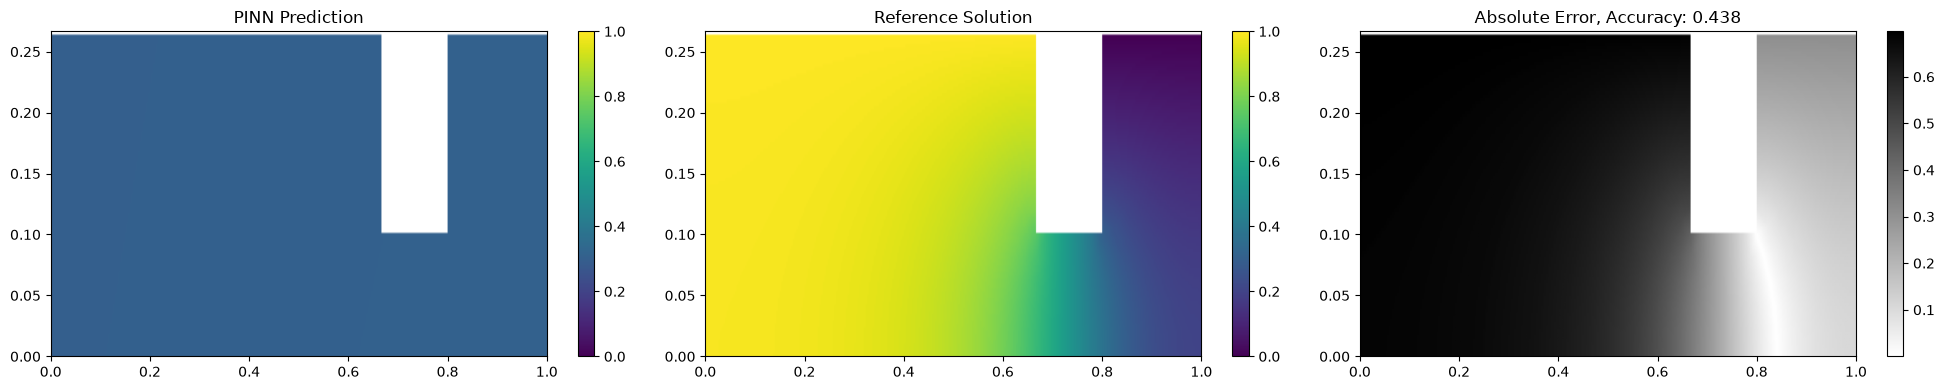

(<Figure size 2000x400 with 6 Axes>,
 array([<Axes: title={'center': 'PINN Prediction'}>,
        <Axes: title={'center': 'Reference Solution'}>,
        <Axes: title={'center': 'Absolute Error, Accuracy: 0.438'}>],
       dtype=object),
 np.float64(0.4375800362792579))

In [95]:
# Set seed for reproducability
set_seed(42)

# simple pinn architecture
arch = [2] + [25] * 6 + [1]
act = nn.Tanh # 
net = MLP(arch, act)
model_view = PINN_trainer(net, device=device)
model_view.evaluate(X_real, Y_real, h_real, domain_bounds=bounds[0], dam_bounds=bounds[1], grid_res=(300, 100), vbounds=(H2, H1))

[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.6796


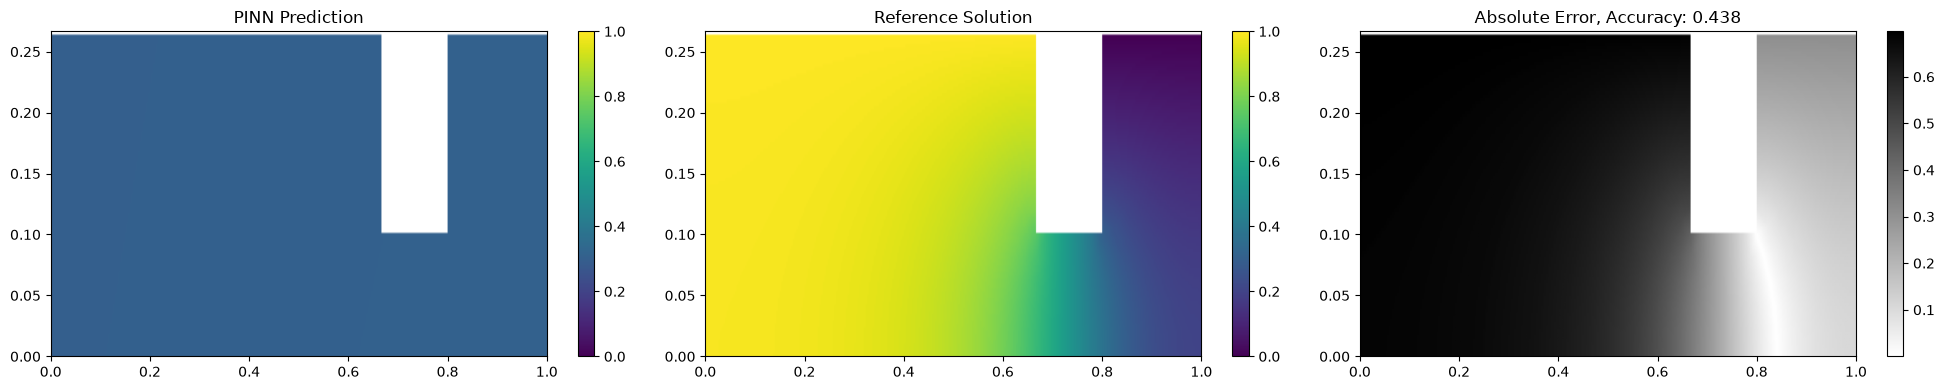

epoch: 0, total_loss: 1.2684e+00pde_loss: 7.2795e-05, h1_loss: 4.8226e-01, h2_loss: 9.5666e-02, vx0_loss: 5.9909e-05, vy0_loss: 1.1080e-05
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.6796


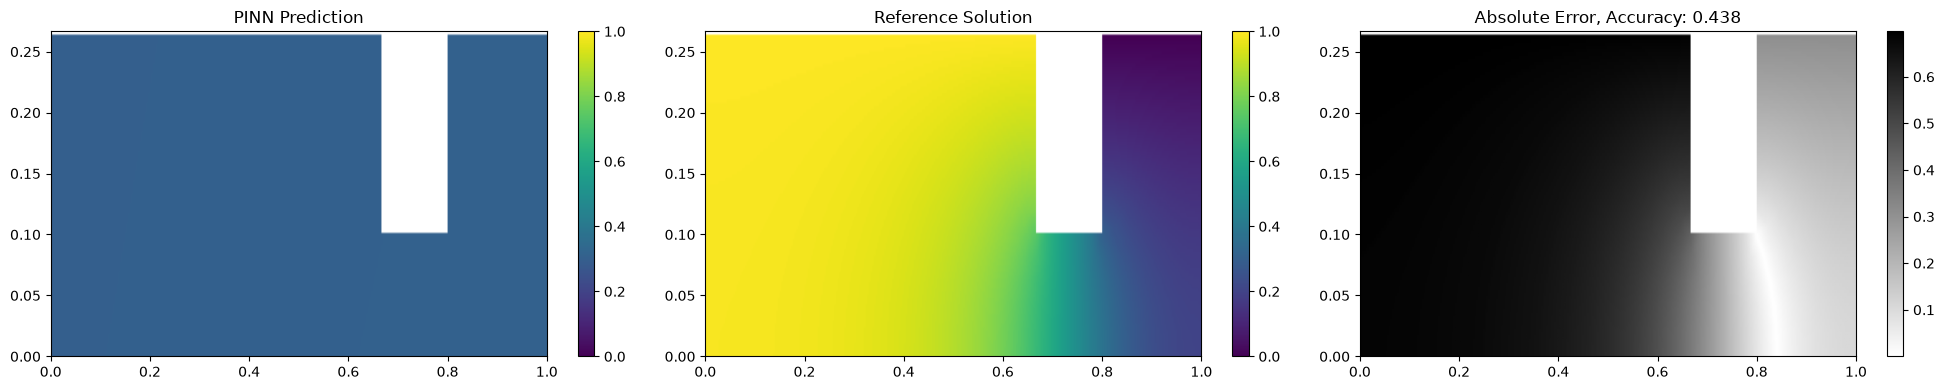

epoch: 1000, total_loss: 1.5553e+00pde_loss: 1.2274e-05, h1_loss: 2.2512e-01, h2_loss: 2.5159e-01, vx0_loss: 4.0801e-04, vy0_loss: 2.2494e-05
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.4897


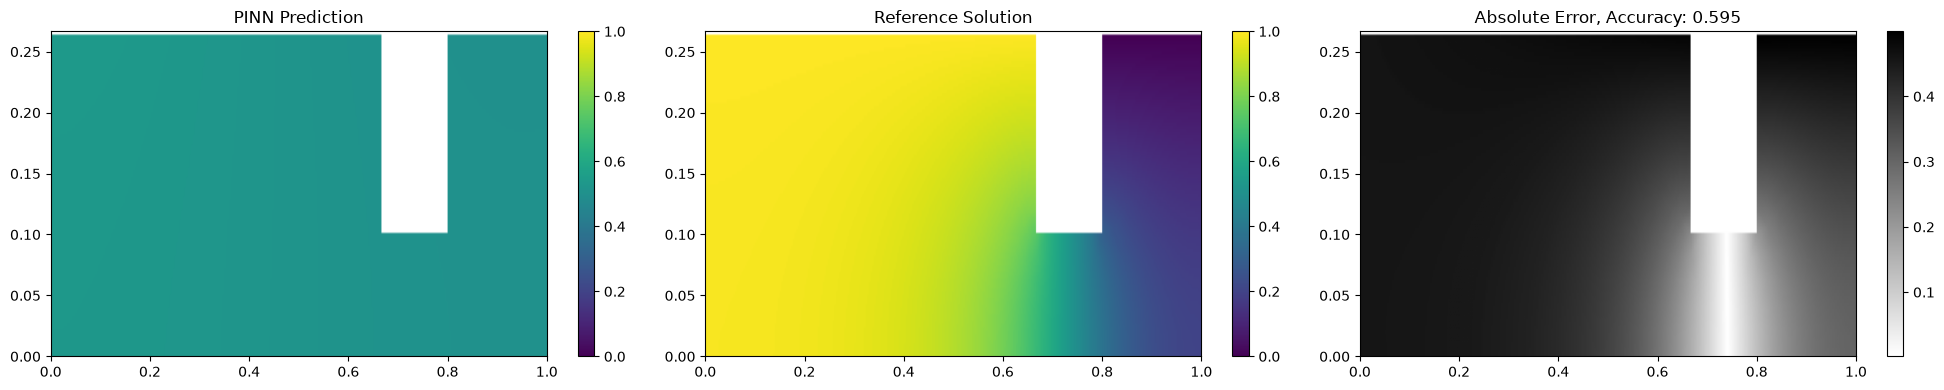

epoch: 2000, total_loss: 2.4087e+00pde_loss: 3.4135e-03, h1_loss: 1.7258e-01, h2_loss: 1.7736e-01, vx0_loss: 1.6064e-02, vy0_loss: 1.0967e-03
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.4198


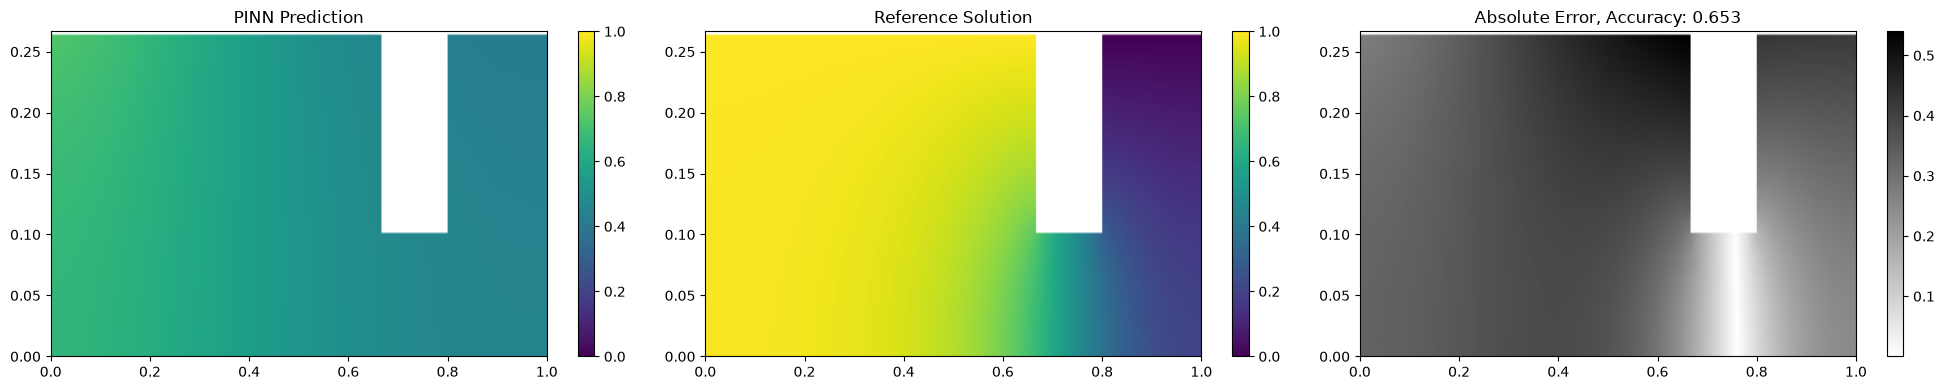

epoch: 3000, total_loss: 3.1759e+00pde_loss: 1.8271e-02, h1_loss: 1.4109e-01, h2_loss: 1.3431e-01, vx0_loss: 3.2260e-02, vy0_loss: 3.9051e-03
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.3585


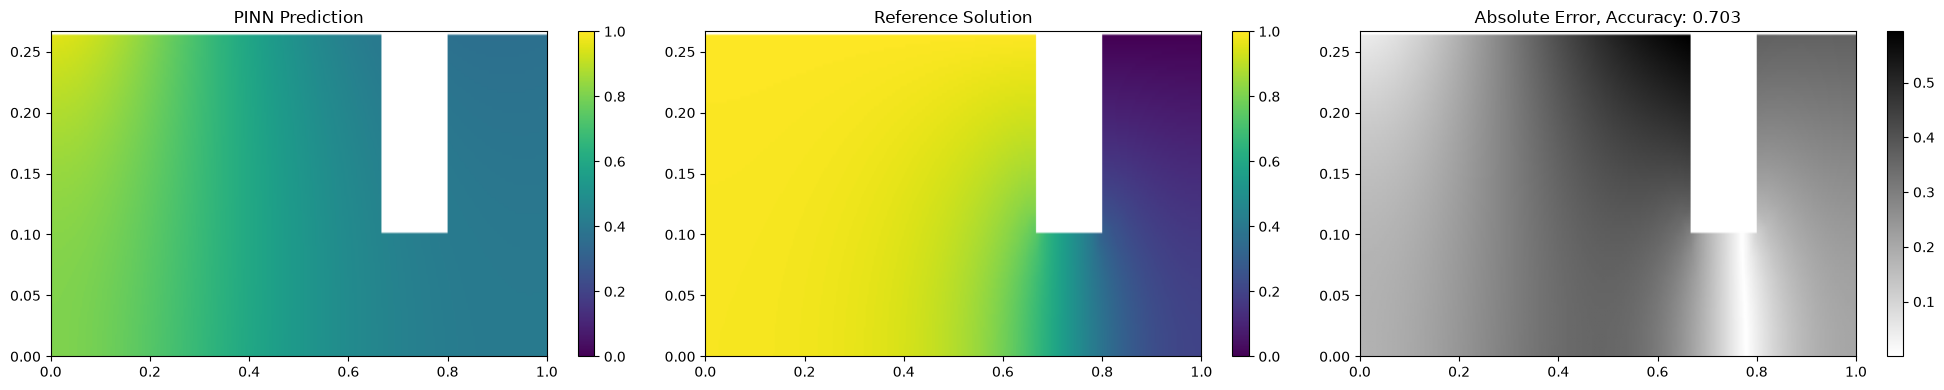

epoch: 4000, total_loss: 4.1175e+00pde_loss: 1.7784e-02, h1_loss: 1.5683e-01, h2_loss: 9.4148e-02, vx0_loss: 4.0733e-02, vy0_loss: 4.1339e-03
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.3533


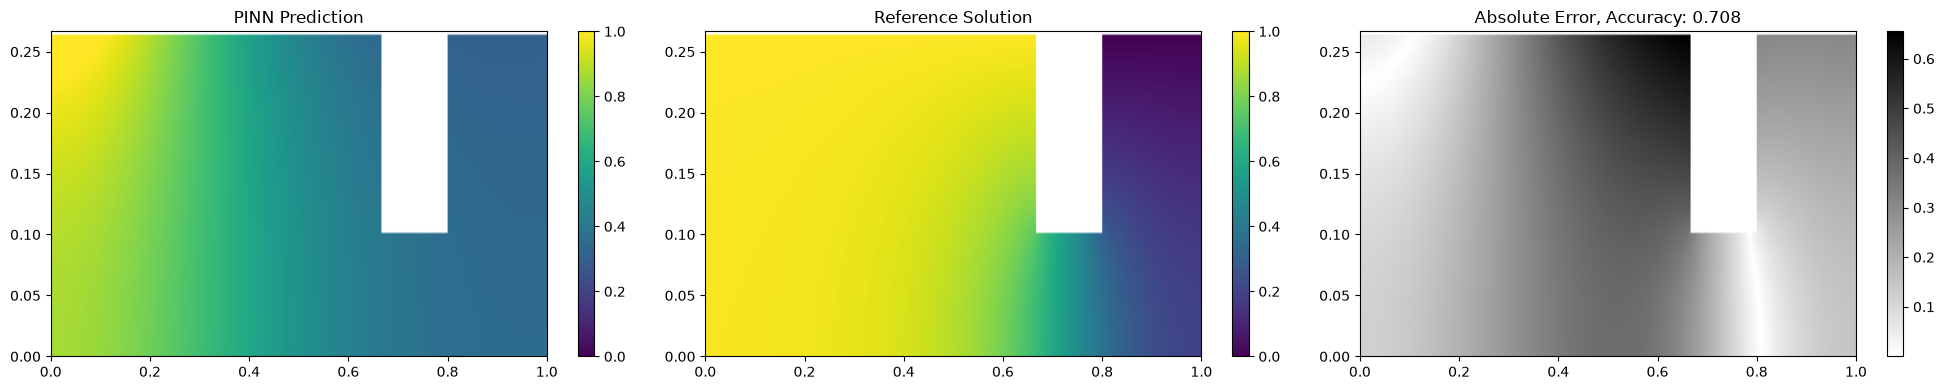

epoch: 5000, total_loss: 5.6201e+00pde_loss: 2.3881e-02, h1_loss: 1.5524e-01, h2_loss: 8.9103e-02, vx0_loss: 4.0065e-02, vy0_loss: 5.1252e-03
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.3478


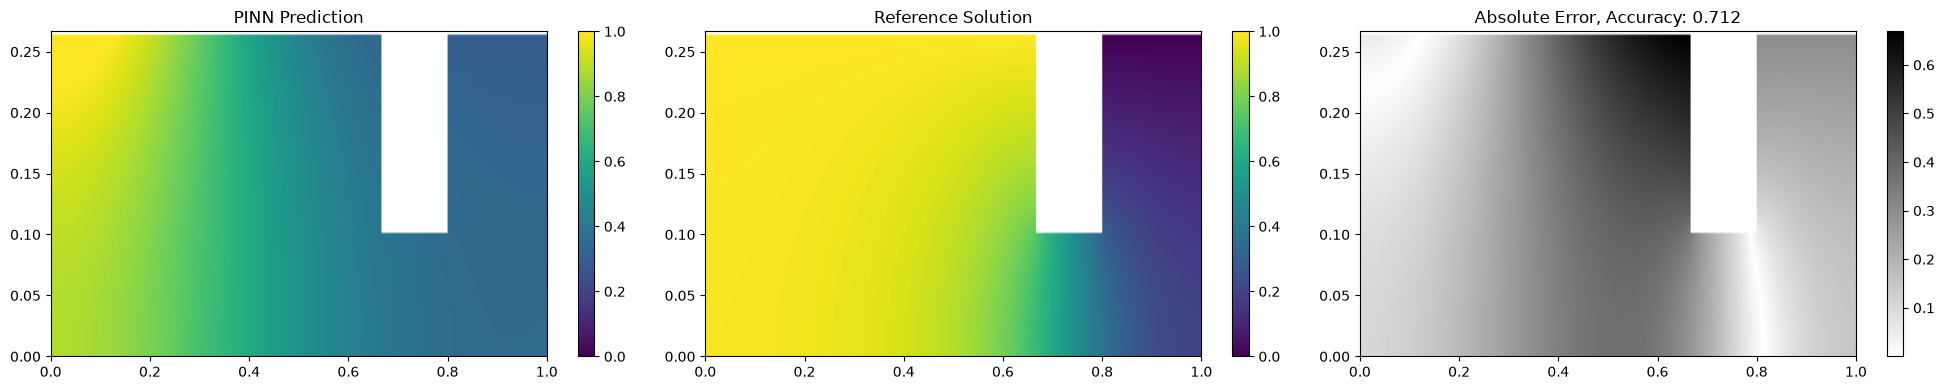

epoch: 6000, total_loss: 1.2100e+01pde_loss: 1.0607e-01, h1_loss: 1.3090e-01, h2_loss: 7.9697e-02, vx0_loss: 4.9673e-02, vy0_loss: 6.4254e-03
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.3164


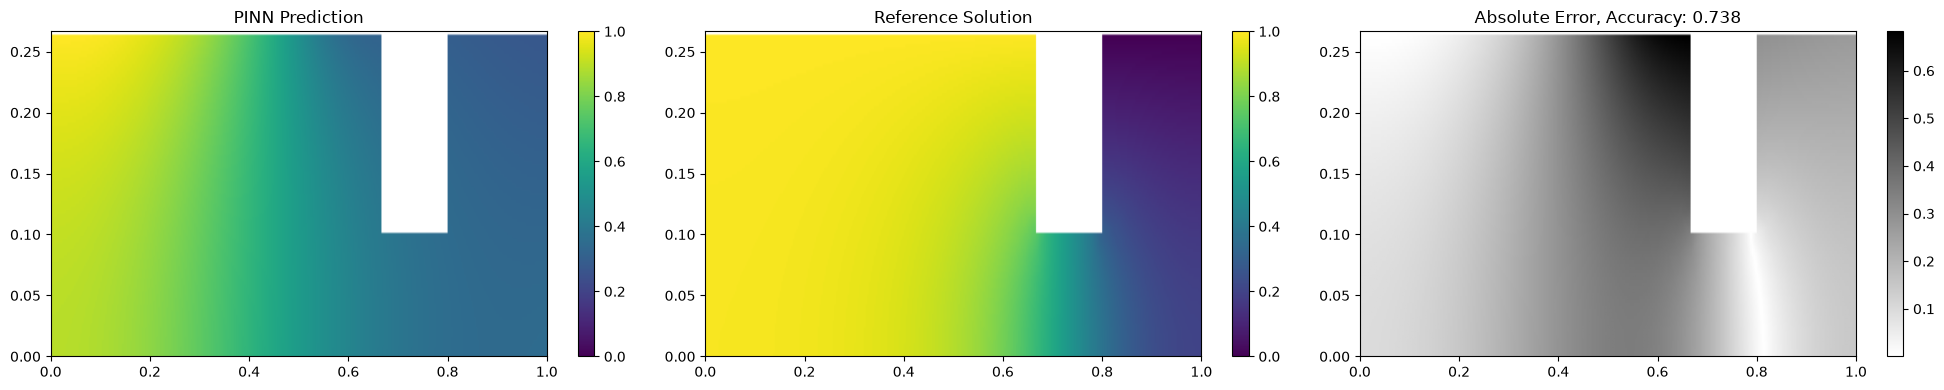

epoch: 7000, total_loss: 5.2861e+01pde_loss: 6.5391e-01, h1_loss: 1.2865e-01, h2_loss: 3.0079e-02, vx0_loss: 7.4924e-02, vy0_loss: 6.7450e-03
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.3055


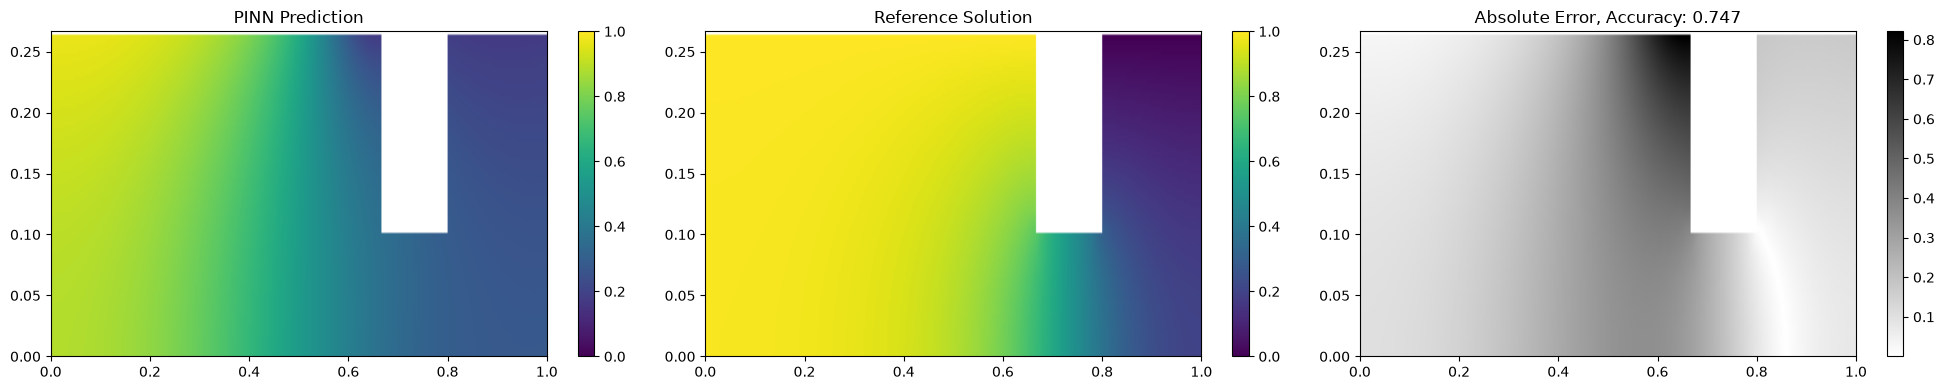

epoch: 8000, total_loss: 6.2185e+01pde_loss: 4.4725e+00, h1_loss: 4.9259e-02, h2_loss: 2.1940e-03, vx0_loss: 1.2807e-01, vy0_loss: 1.3023e-02
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.1989


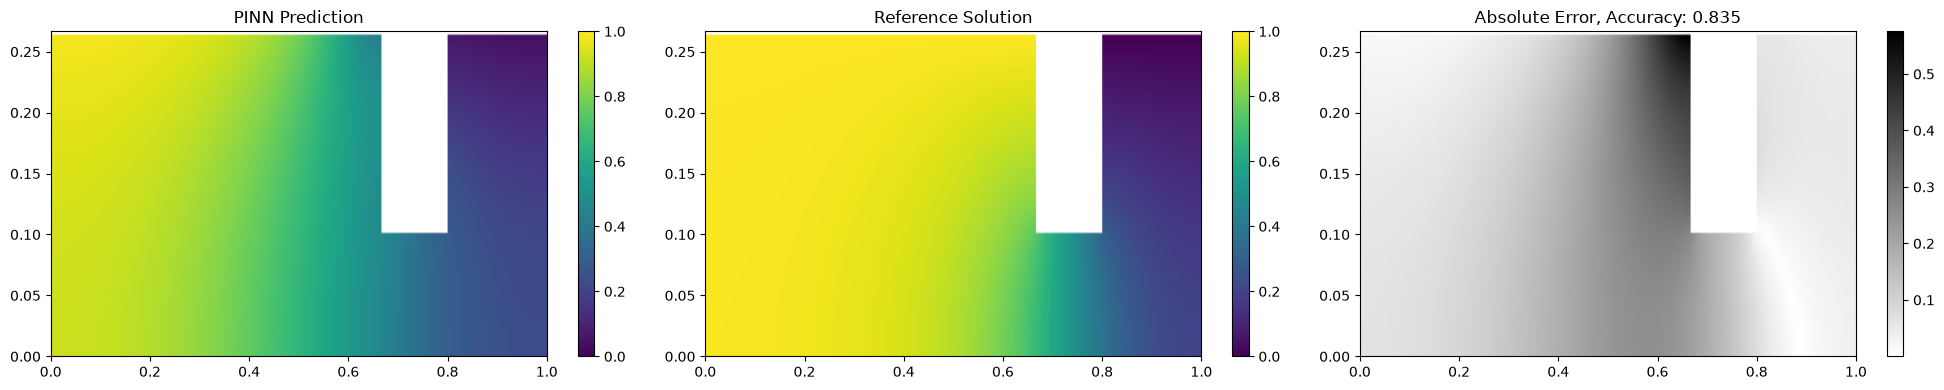

epoch: 9000, total_loss: 1.0797e+02pde_loss: 1.2004e+01, h1_loss: 1.0277e-02, h2_loss: 1.6741e-03, vx0_loss: 1.4269e-01, vy0_loss: 1.8057e-02
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.1207


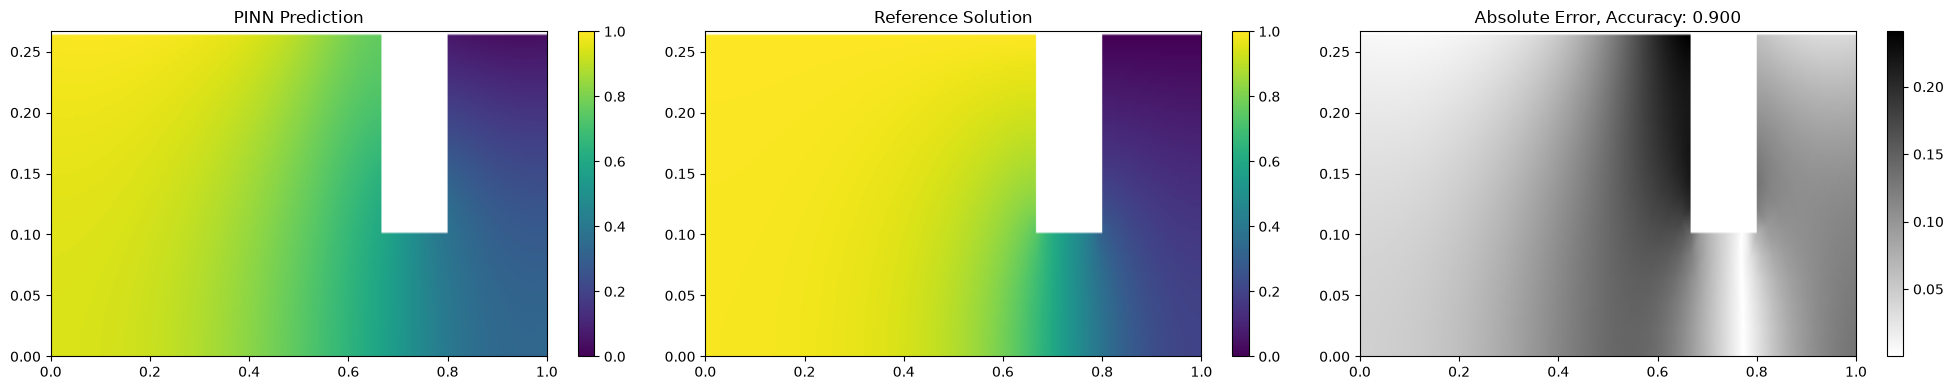

epoch: 10000, total_loss: 1.3569e+02pde_loss: 3.2586e+01, h1_loss: 1.3167e-03, h2_loss: 7.3295e-04, vx0_loss: 5.6771e-02, vy0_loss: 2.0821e-02
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.1064


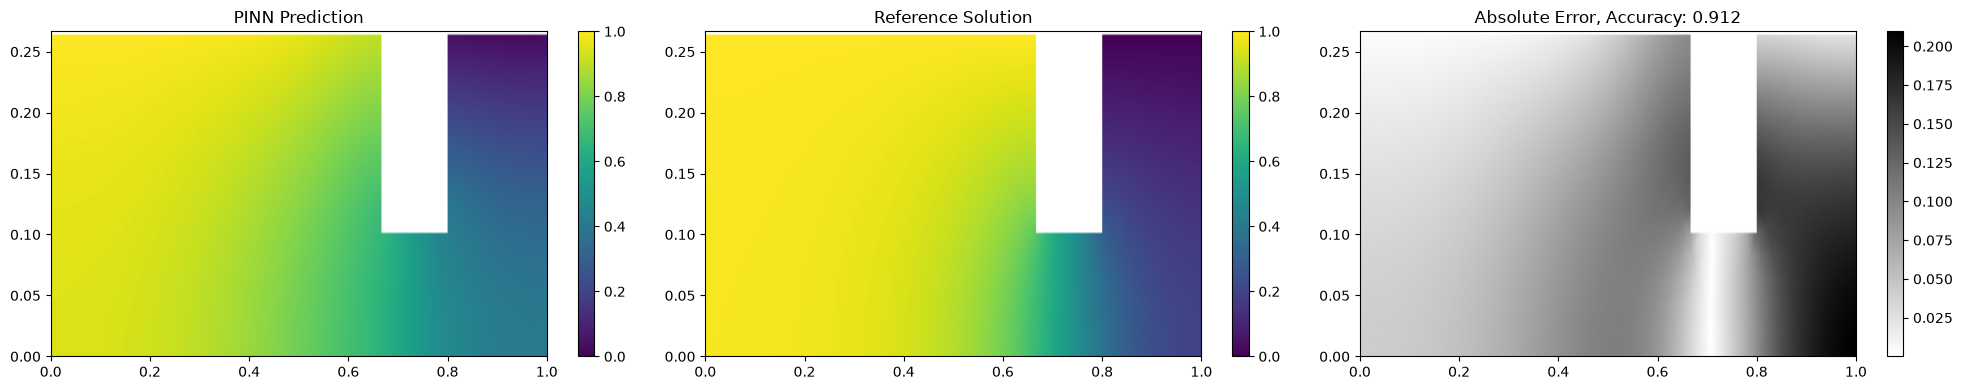

epoch: 11000, total_loss: 1.1751e+02pde_loss: 6.6666e+01, h1_loss: 1.3800e-04, h2_loss: 1.1160e-04, vx0_loss: 1.9804e-02, vy0_loss: 1.2836e-02
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.1252


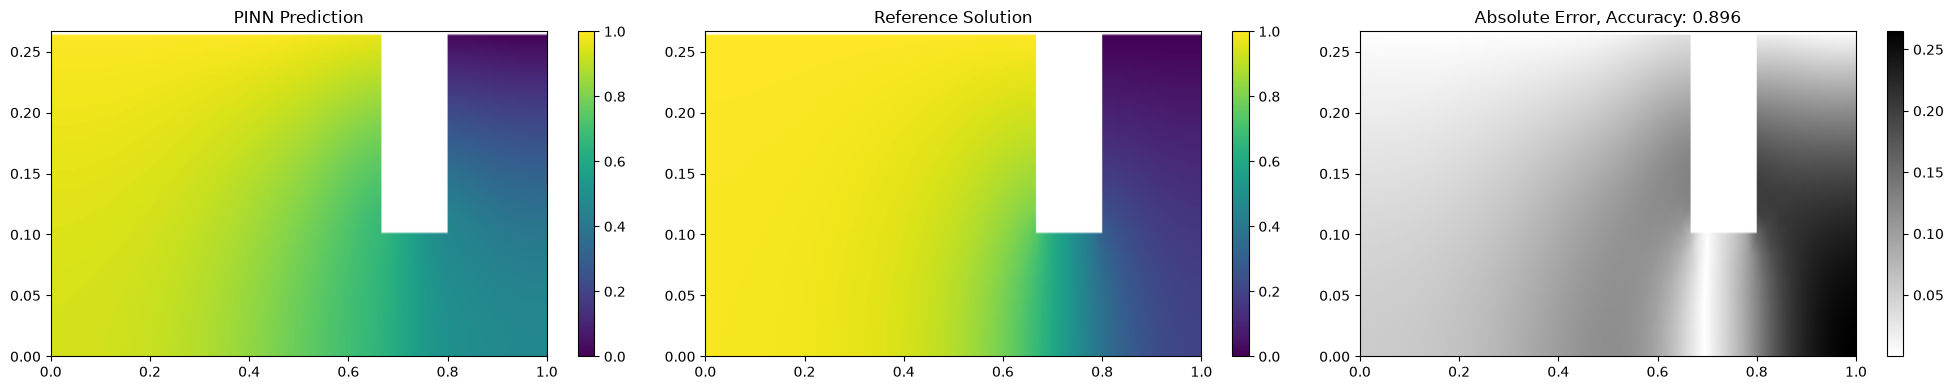

epoch: 12000, total_loss: 1.5820e+02pde_loss: 7.6017e+01, h1_loss: 1.0522e-04, h2_loss: 2.5449e-05, vx0_loss: 1.3883e-02, vy0_loss: 1.0898e-02
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.1292


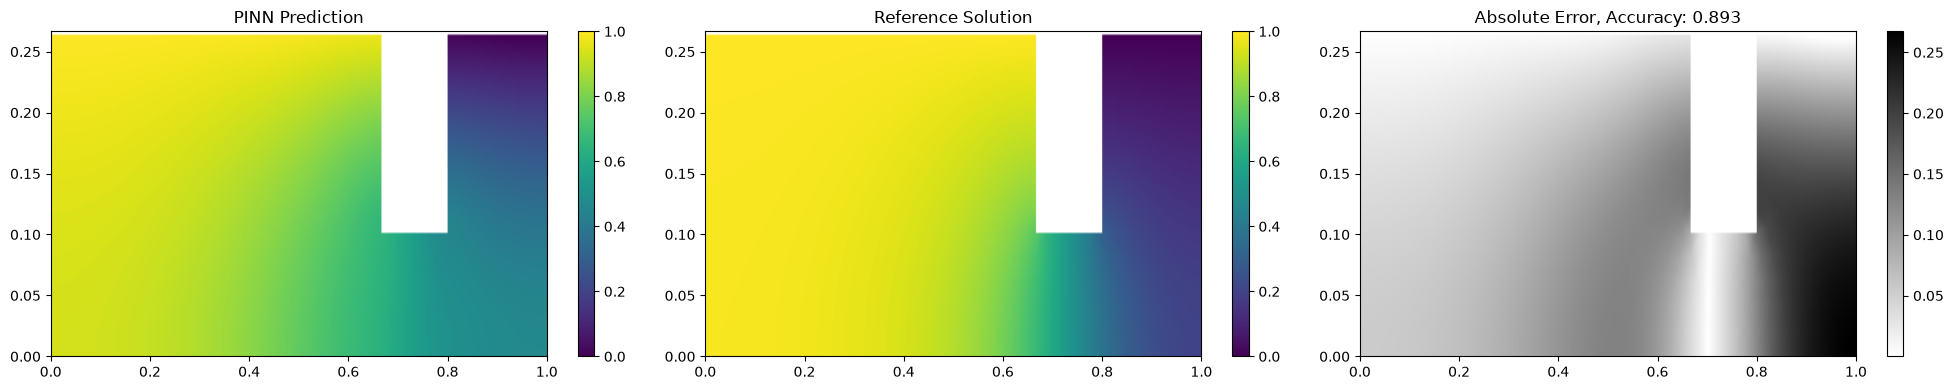

epoch: 13000, total_loss: 1.1661e+02pde_loss: 1.0697e+02, h1_loss: 1.5577e-05, h2_loss: 3.2266e-05, vx0_loss: 5.0366e-03, vy0_loss: 2.4821e-03
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.1448


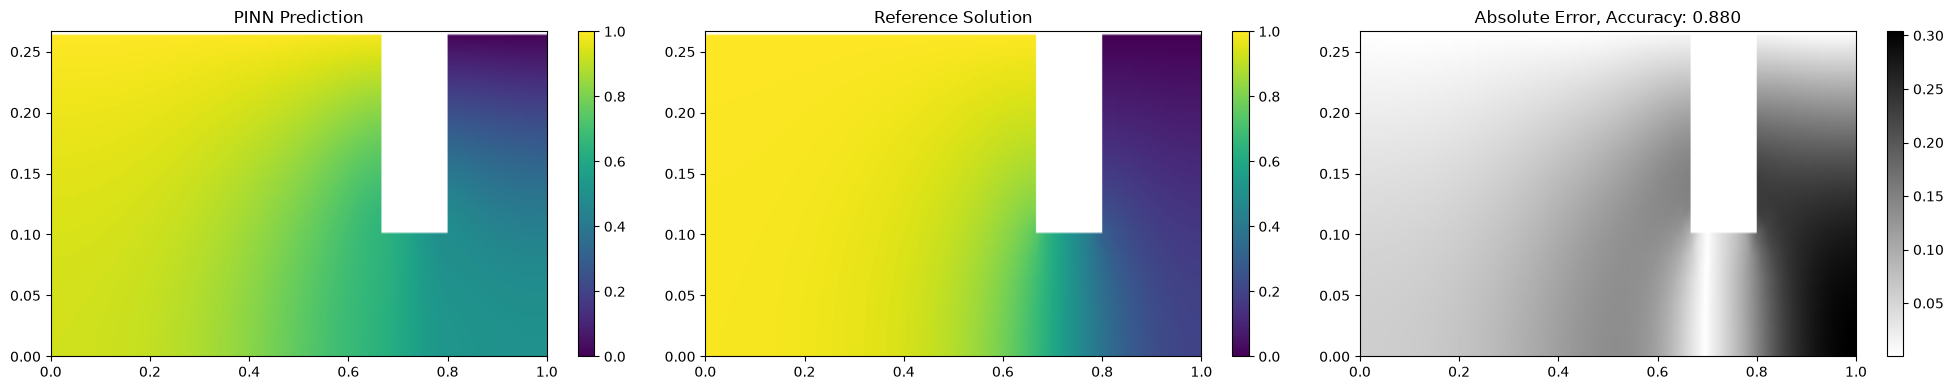

epoch: 14000, total_loss: 2.7904e+02pde_loss: 6.9305e+01, h1_loss: 6.5024e-05, h2_loss: 7.5370e-05, vx0_loss: 1.3397e-02, vy0_loss: 1.2818e-02
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.1267


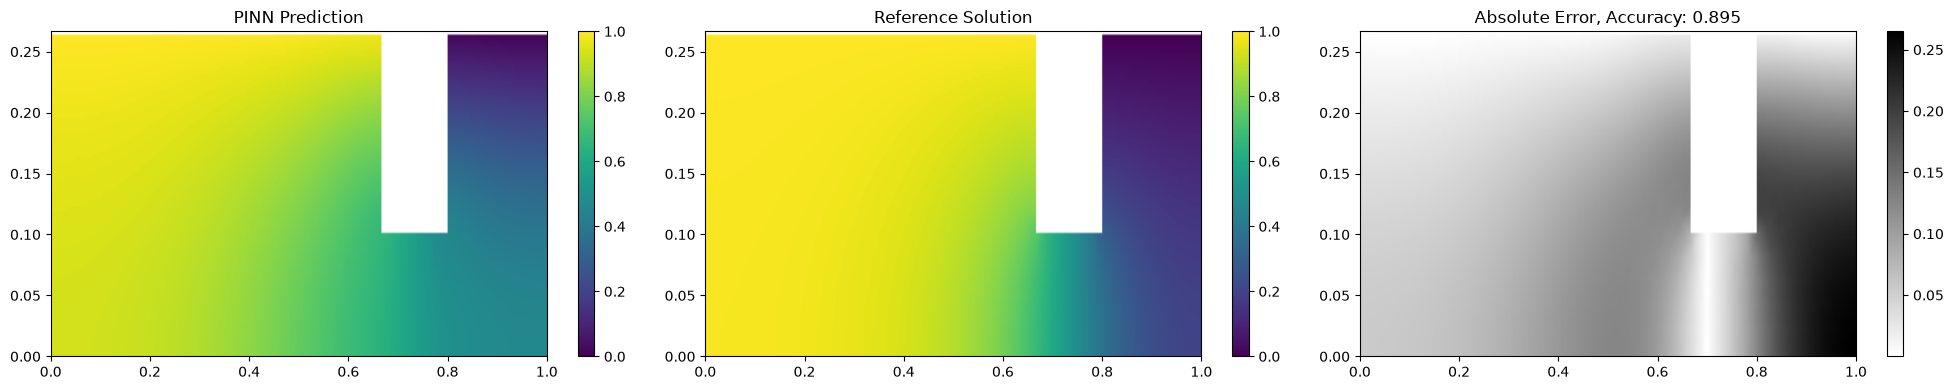

[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.1750


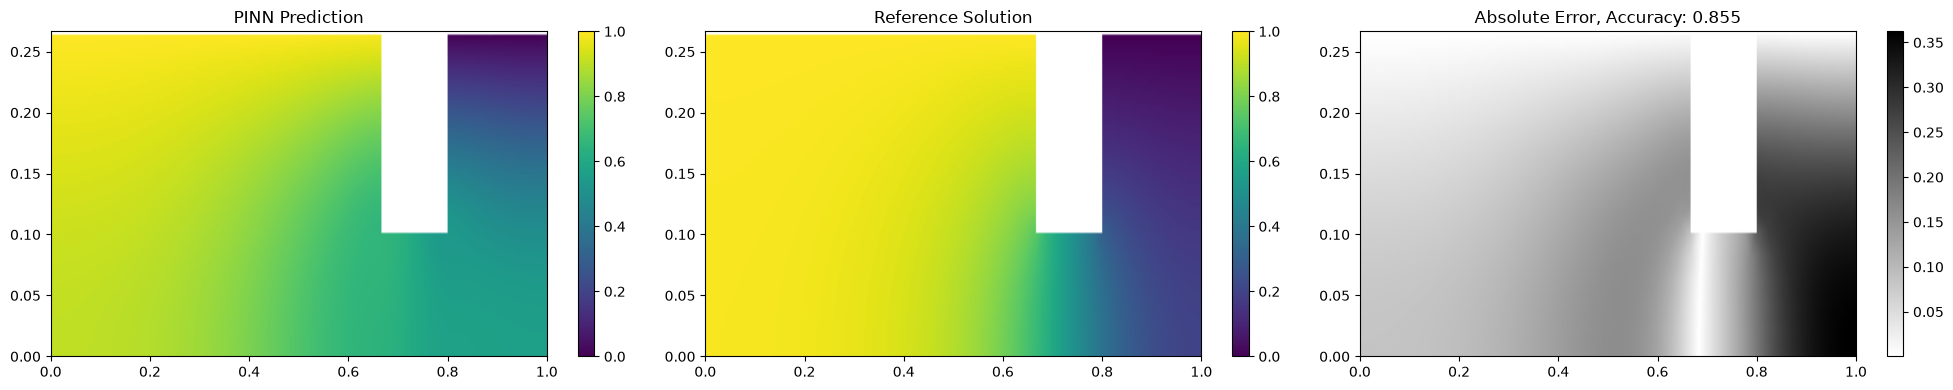

(<Figure size 2000x400 with 6 Axes>,
 array([<Axes: title={'center': 'PINN Prediction'}>,
        <Axes: title={'center': 'Reference Solution'}>,
        <Axes: title={'center': 'Absolute Error, Accuracy: 0.855'}>],
       dtype=object),
 np.float64(0.8551841441707342))

In [96]:
# Set seed for reproducability
set_seed(42)

# simple pinn architecture
arch = [2] + [25] * 6 + [1]
act = nn.Tanh # 
net = MLP(arch, act)

model_aw = PINN_trainer(net, device=device)
model_aw.evaluate(X_real, Y_real, h_real, domain_bounds=bounds[0], dam_bounds=bounds[1], grid_res=(300, 100))



EPOCHS = 15000

NTK_BATCH_SIZE = 300  # Batch size for NTK calculations
WEIGHT_UPDATE_INTERVAL = 1000  # Update weights every 1000 iterations

ADAPTIVE_SAMPLING_METHOD = 'gar'  # gar or rar
RESAMPLE_FREQUENCY = 1000  # Resample every 1000 epochs
NUM_ADAPTIVE_BASE_POINTS = 30000 # Number of base points for adaptive sampling
NUM_ADAPTIVE_POINTS = 2000 # Number of adaptive points to sample from those base points


ETA_INIT = 1e-3                  # Initial learning rate


optimizer = torch.optim.Adam(model_aw.parameters(), lr=ETA_INIT)
loss_fn = torch.nn.MSELoss()  # Loss function
# Scheduler

'''
SCHEDULER_STEP_SIZE = 1000 # LR multiplied by GAMMA every 1000 epochs
GAMMA = 0.9               # LR multiplid by this factor
# Multiplies LR by 0.9 every 1000 epochs
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=SCHEDULER_STEP_SIZE, gamma=GAMMA
)
'''


'''
ETA_MIN = 1e-4
# Cosine Annealing automatically scales LR smoothly down to eta_min
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=ETA_MIN
)
'''


#x_internal = torch.tensor(x_internal, dtype=torch.float32, requires_grad=True, device=device)
#y_internal = torch.tensor(y_internal, dtype=torch.float32, requires_grad=True, device=device)
#input_internal = torch.cat((x_internal,y_internal), dim=1).requires_grad_()

h1_losses = []
h2_losses = []
vx0_losses = []
vy0_losses = []
pde_losses = []

losses = []

target_accuracy = 0.9


for epoch in range(EPOCHS):
    # tells the model that you are training
    model_aw.train()
    optimizer.zero_grad()
    # don't resample
    #if epoch % RESAMPLE_FREQUENCY == 0
    # sample new collocation points

    #
    

    '''
    h = model_aw(input_internal)
    h_x = torch.autograd.grad(h, x_internal,
                            grad_outputs=torch.ones_like(h),
                            create_graph=True, retain_graph=True)[0]
    h_xx = torch.autograd.grad(h_x, x_internal,
                            grad_outputs=torch.ones_like(h),
                            create_graph=True, retain_graph=True)[0]
    h_y = torch.autograd.grad(h, y_internal,
                            grad_outputs=torch.ones_like(h),
                            create_graph=True, retain_graph=True)[0]
    h_yy = torch.autograd.grad(h_y, y_internal,
                            grad_outputs=torch.ones_like(h),
                            create_graph=True, retain_graph=True)[0]
    pde_residual = h'''
    pde_residual = model_aw.pde_residual(x_internal, y_internal)
    pde_loss = torch.mean(pde_residual**2)#loss_fn(pde_residual, torch.zeros_like(pde_residual))

    h1_forward = model_aw.net_forward(x_bc_h1, y_bc_h1)
    h1_residual = h1_forward - torch.full_like(h1_forward, H1, device=device)#model_aw.bc_value_residual(x_bc_h1, y_bc_h1, H1)
    h1_loss = loss_fn(h1_residual, torch.zeros_like(h1_residual))

    h2_forward = model_aw.net_forward(x_bc_h2, y_bc_h2)
    h2_residual = h2_forward - torch.full_like(h2_forward, H2, device=device)
    h2_loss = loss_fn(h2_residual, torch.zeros_like(h2_residual))

    #vx0_forward = model_aw.net_forward(x_bc_vx0, y_bc_vx0)
    vx0_residual = model_aw.bc_velocity_residual(x_bc_vx0, y_bc_vx0, 'x')
    vx0_loss = loss_fn(vx0_residual, torch.zeros_like(vx0_residual))

    #vy0_forward = model_aw.net_forward(x_bc_vy0, y_bc_vy0)
    vy0_residual = model_aw.bc_velocity_residual(x_bc_vy0, y_bc_vy0, 'y')
    vy0_loss = loss_fn(vy0_residual, torch.zeros_like(vy0_residual))

    

    if epoch % WEIGHT_UPDATE_INTERVAL == 0:
        # Calculate NTK-based adaptive weights
        ntk_weights = model_aw.calculate_adaptive_weights(
            [
                pde_residual,
                h1_forward,
                h2_forward,
                vx0_residual,
                vy0_residual
            ],
            sampling_strategy='random',
            batch_size=NTK_BATCH_SIZE,
            return_info=False
        )
        #pde_weight = ntk_weights[0]
        pde_weight, h1_weight, h2_weight, vx0_weight, vy0_weight = ntk_weights
        #h1_weight, h2_weight, vx0_weight, vy0_weight = ntk_weights
    
    total_loss = pde_weight * pde_loss \
                + h1_weight * h1_loss \
                + h2_weight * h2_loss \
                + vx0_weight * vx0_loss \
                + vy0_weight * vy0_loss

    if epoch % WEIGHT_UPDATE_INTERVAL == 0:
        print(f"epoch: {epoch}, "
            f"total_loss: {total_loss.item():.4e}"
            f"pde_loss: {pde_loss.item():.4e}, "
            f"h1_loss: {h1_loss.item():.4e}, "
            f"h2_loss: {h2_loss.item():.4e}, "
            f"vx0_loss: {vx0_loss.item():.4e}, "
            f"vy0_loss: {vy0_loss.item():.4e}")
        
        fig, ax, acc = model_aw.evaluate(X_real, Y_real, h_real, domain_bounds=bounds[0], dam_bounds=bounds[1], grid_res=(300, 100), vbounds=(H2, H1))
    

    losses.append(total_loss.item())
    h1_losses.append(h1_loss.item())
    h2_losses.append(h2_loss.item())
    vx0_losses.append(vx0_loss.item())
    vy0_losses.append(vy0_loss.item())
    pde_losses.append(pde_loss.item())

    
    total_loss.backward()
    optimizer.step()
    # --- Update Learning Rate ---
    #scheduler.step()

model_aw.evaluate(X_real, Y_real, h_real, domain_bounds=bounds[0], dam_bounds=bounds[1], grid_res=(300, 100), vbounds=(H2, H1))
    
    



    
    
    


Use `LBFGS` for second training process

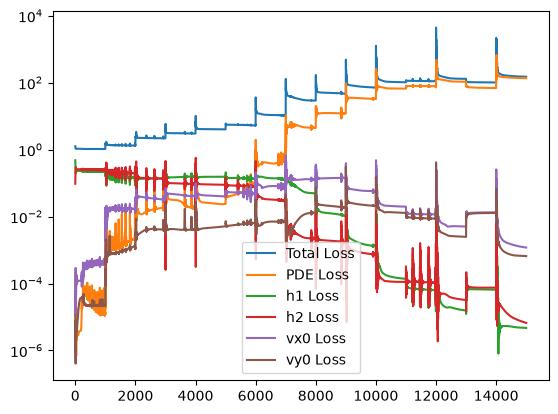

In [100]:
epochs = np.array([i for i in range(len(losses))])

plt.plot(epochs, losses, label="Total Loss")
plt.plot(epochs, pde_losses, label="PDE Loss")
plt.plot(epochs, h1_losses, label="h1 Loss")
plt.plot(epochs, h2_losses, label="h2 Loss")
plt.plot(epochs, vx0_losses, label="vx0 Loss")
plt.plot(epochs, vy0_losses, label="vy0 Loss")
plt.yscale("log")
plt.legend()
plt.show()

iteration: 0, pde_loss: 1.3673e+02, h1_loss: 4.7068e-06, h2_loss: 6.6584e-06, vx0_loss: 1.1904e-03, vy0_loss: 6.6012e-04
iteration: 0, pde_weight: 1.0010e+00, h1_weight: 2.5745e+04, h2_weight: 1.6101e+04, vx0_weight: 3.0097e+03, vy0_weight: 1.9277e+03
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.1750


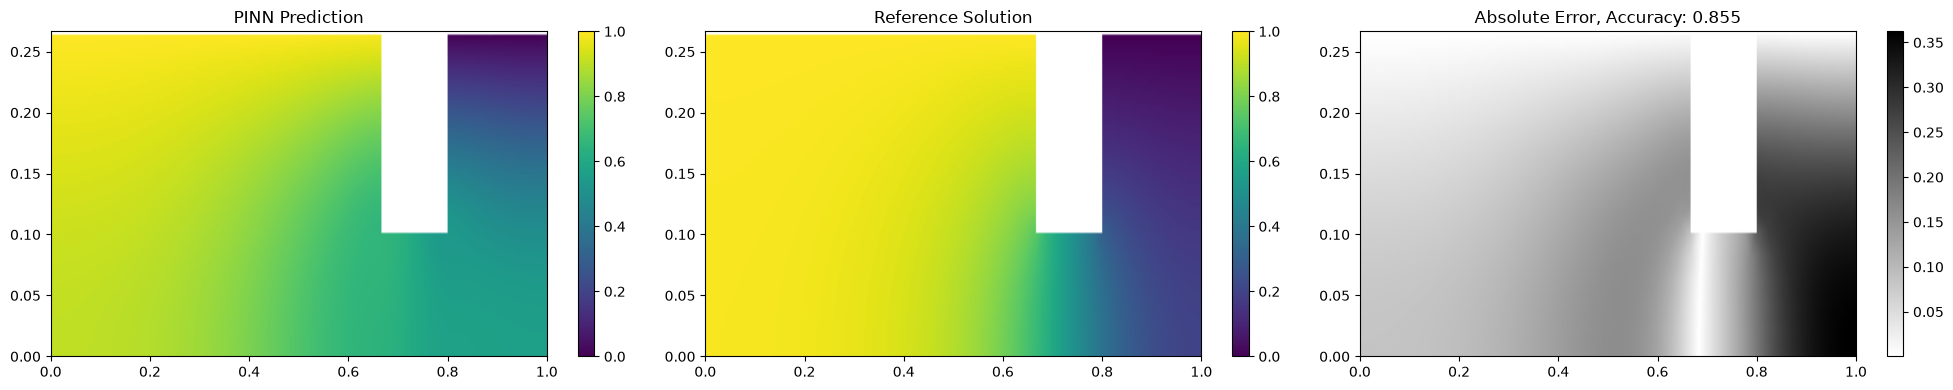

iteration: 1000, pde_loss: 6.7501e+01, h1_loss: 2.6271e-05, h2_loss: 3.0259e-05, vx0_loss: 2.8010e-03, vy0_loss: 5.6258e-03
iteration: 1000, pde_weight: 1.0002e+00, h1_weight: 4.5393e+05, h2_weight: 3.3792e+05, vx0_weight: 7.6473e+03, vy0_weight: 1.6786e+04
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.1214


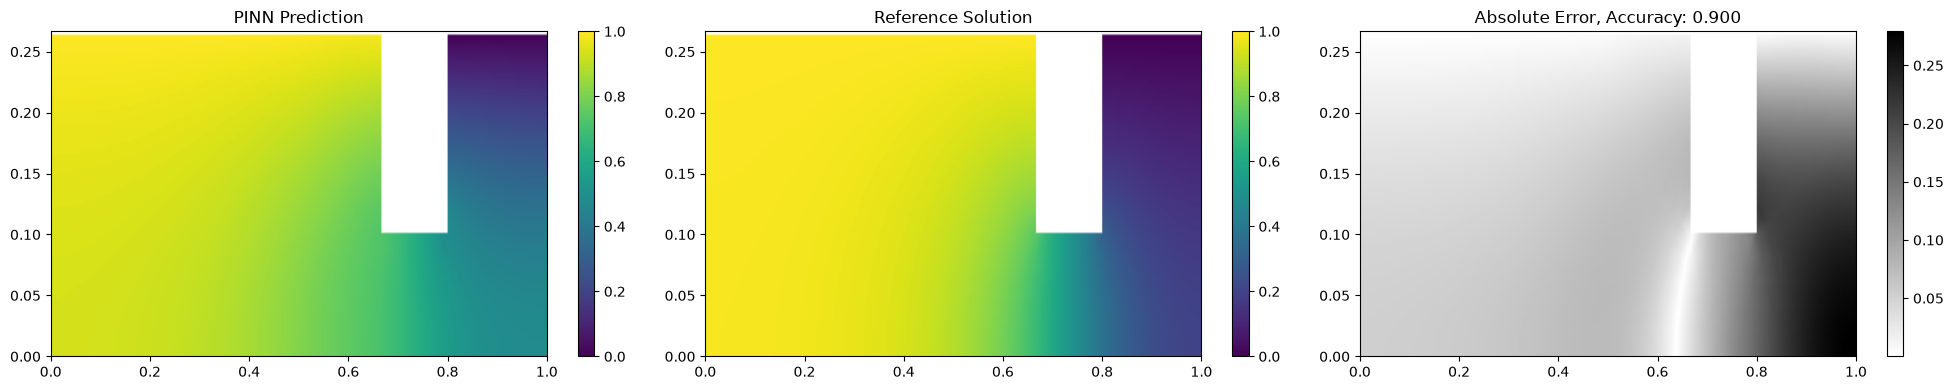

[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.1214


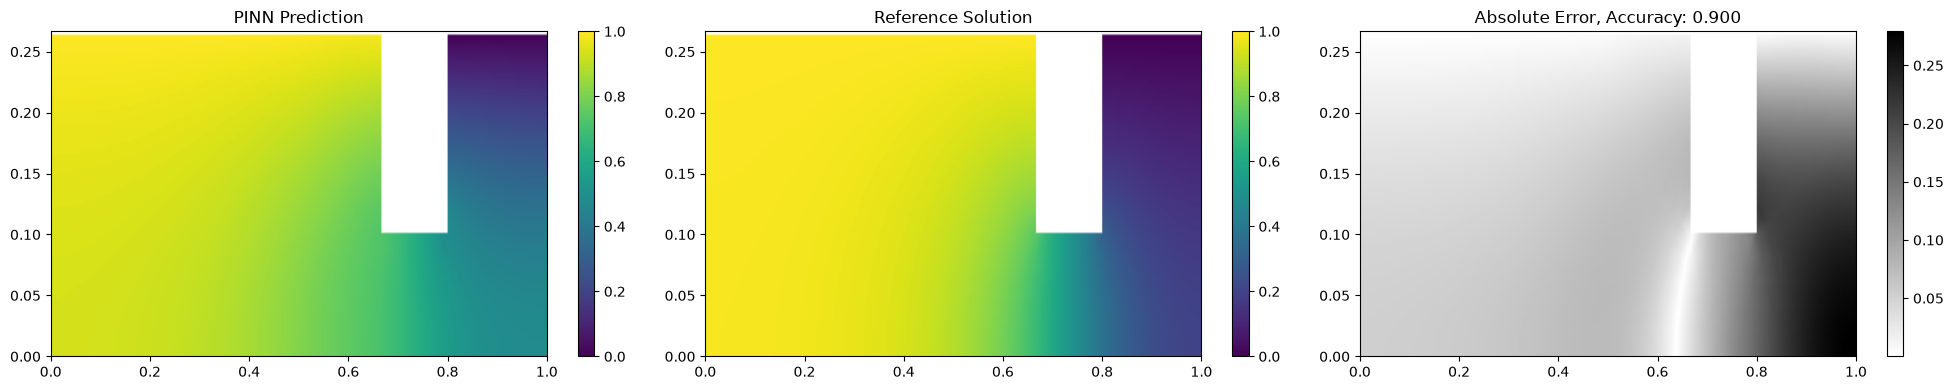

(<Figure size 2000x400 with 6 Axes>,
 array([<Axes: title={'center': 'PINN Prediction'}>,
        <Axes: title={'center': 'Reference Solution'}>,
        <Axes: title={'center': 'Absolute Error, Accuracy: 0.900'}>],
       dtype=object),
 np.float64(0.8995684236805916))

In [97]:
ETA_LBFGS = 1e-1

# 1. Instantiate a new model instance with the same architecture
model_lbfgs = PINN_trainer(net, device=device)

# 2. Copy over the weights from the trained model
model_lbfgs.load_state_dict(model_aw.state_dict())


optimizer_lbfgs = torch.optim.LBFGS(model_lbfgs.parameters(), lr=ETA_LBFGS, max_iter=10000, max_eval=None, history_size=100, tolerance_grad=1e-8, tolerance_change=1e-8, line_search_fn='strong_wolfe')
iteration = 0
def closure():
    global iteration
    global pde_weight, h1_weight, h2_weight, vx0_weight, vy0_weight
    optimizer_lbfgs.zero_grad()

    pde_residual = model_lbfgs.pde_residual(x_internal, y_internal)
    pde_loss = torch.mean(pde_residual**2)#loss_fn(pde_residual, torch.zeros_like(pde_residual))

    h1_forward = model_lbfgs.net_forward(x_bc_h1, y_bc_h1)
    h1_residual = h1_forward - torch.full_like(h1_forward, H1, device=device)#model_aw.bc_value_residual(x_bc_h1, y_bc_h1, H1)
    h1_loss = loss_fn(h1_residual, torch.zeros_like(h1_residual))

    h2_forward = model_lbfgs.net_forward(x_bc_h2, y_bc_h2)
    h2_residual = h2_forward - torch.full_like(h2_forward, H2, device=device)
    h2_loss = loss_fn(h2_residual, torch.zeros_like(h2_residual))

    #vx0_forward = model_lbfgs.net_forward(x_bc_vx0, y_bc_vx0)
    vx0_residual = model_lbfgs.bc_velocity_residual(x_bc_vx0, y_bc_vx0, 'x')
    vx0_loss = loss_fn(vx0_residual, torch.zeros_like(vx0_residual))

    #vy0_forward = model_lbfgs.net_forward(x_bc_vy0, y_bc_vy0)
    vy0_residual = model_lbfgs.bc_velocity_residual(x_bc_vy0, y_bc_vy0, 'y')
    vy0_loss = loss_fn(vy0_residual, torch.zeros_like(vy0_residual))
    
    total_loss = pde_weight * pde_loss \
                                + h1_weight * h1_loss \
                                + h2_weight * h2_loss \
                                + vx0_weight * vx0_loss \
                                + vy0_weight * vy0_loss


    if iteration % WEIGHT_UPDATE_INTERVAL == 0:
        # Calculate NTK-based adaptive weights
        print(f"iteration: {iteration}, "
                        f"pde_loss: {pde_loss.item():.4e}, "
                        f"h1_loss: {h1_loss.item():.4e}, "
                        f"h2_loss: {h2_loss.item():.4e}, "
                        f"vx0_loss: {vx0_loss.item():.4e}, "
                        f"vy0_loss: {vy0_loss.item():.4e}")
        ntk_weights = model_lbfgs.calculate_adaptive_weights(
            [
                pde_residual,
                h1_forward,
                h2_forward,
                vx0_residual,
                vy0_residual
            ],
            sampling_strategy='random',
            batch_size=NTK_BATCH_SIZE,
            return_info=False
        )
        
        pde_weight, h1_weight, h2_weight, vx0_weight, vy0_weight = ntk_weights
    
        print(f"iteration: {iteration}, "
                                                f"pde_weight: {pde_weight.item():.4e}, "
                                                f"h1_weight: {h1_weight.item():.4e}, "
                                                f"h2_weight: {h2_weight.item():.4e}, "
                                                f"vx0_weight: {vx0_weight.item():.4e}, "
                                                f"vy0_weight: {vy0_weight.item():.4e}")
        model_aw.evaluate(X_real, Y_real, h_real, domain_bounds=bounds[0], dam_bounds=bounds[1], grid_res=(300, 100), vbounds=(H2, H1))
            
    total_loss.backward()
    iteration += 1
    return total_loss
            
            

optimizer_lbfgs.step(closure)
model_aw.evaluate(X_real, Y_real, h_real, domain_bounds=bounds[0], dam_bounds=bounds[1], grid_res=(300, 100), vbounds=(H2, H1))

[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.1214


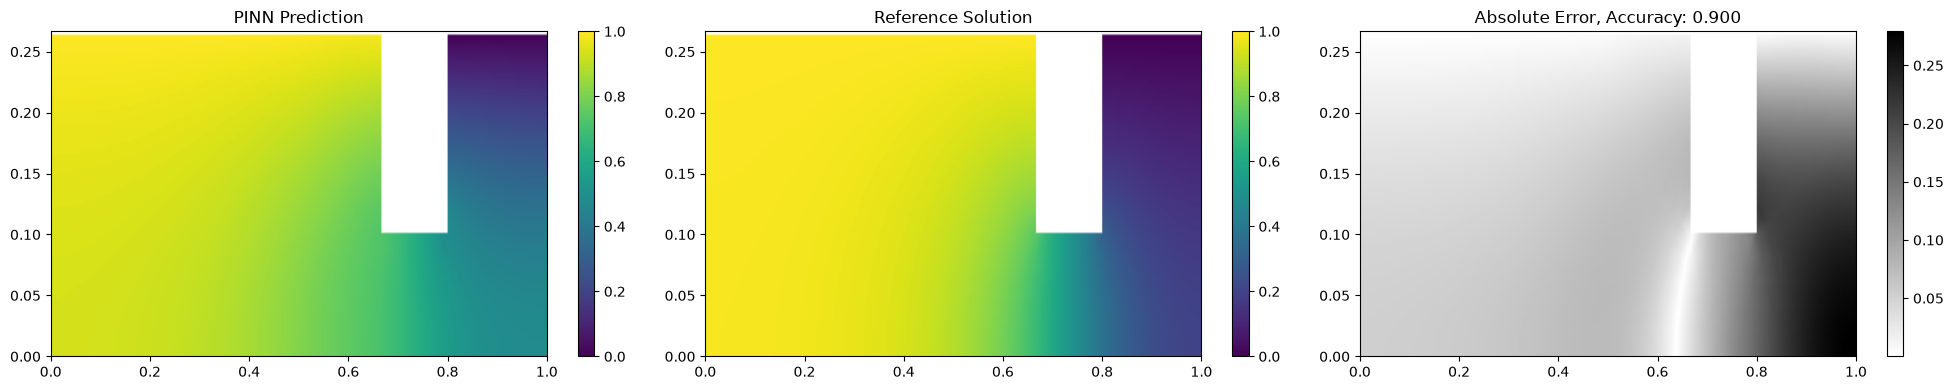

[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.1214


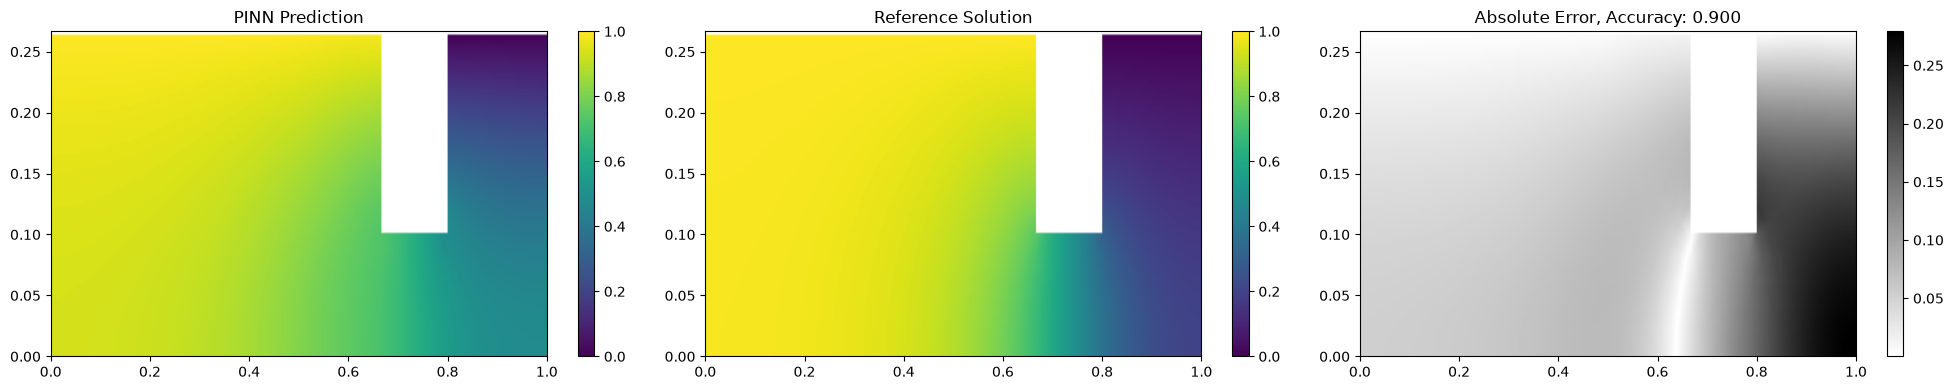

(<Figure size 2000x400 with 6 Axes>,
 array([<Axes: title={'center': 'PINN Prediction'}>,
        <Axes: title={'center': 'Reference Solution'}>,
        <Axes: title={'center': 'Absolute Error, Accuracy: 0.900'}>],
       dtype=object),
 np.float64(0.8995684236805916))

In [ ]:
model_aw.evaluate(X_real, Y_real, h_real, domain_bounds=bounds[0], dam_bounds=bounds[1], grid_res=(300, 100), vbounds=(H2, H1))


20260723_150841
[0.         0.0012837  0.00256739 ... 0.99743261 0.9987163  1.        ]
(74360, 1) (74360, 1) (74360, 1)
diff.shape = (300, 100), h_real_display.shape =(300, 100)
L2 Normalized Relative Error: 0.1214


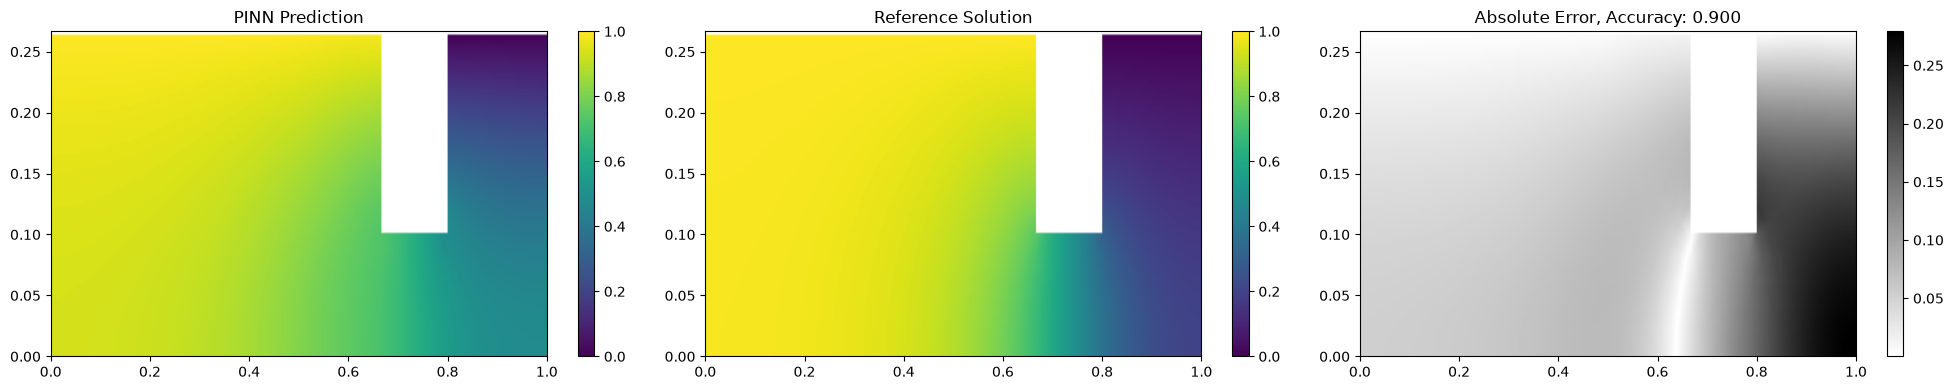

In [104]:
import datetime
import os

now = str(datetime.datetime.now().strftime("%Y%m%d_%H%M%S"))
print(now)
save_dir = os.path.join("../Results",f"weights_{now}")
os.makedirs(save_dir)

model_aw.save_weights(os.path.join(save_dir, f"adam.pt"))
model_lbfgs.save_weights(os.path.join(save_dir, f"adam+lbfgs.pt"))

fig, ax, acc = model_lbfgs.evaluate(X_real, Y_real, h_real, domain_bounds=bounds[0], dam_bounds=bounds[1], grid_res=(300, 100), vbounds=(H2, H1))
fig.savefig(os.path.join(save_dir, "LBFGS_predictions.png"), dpi=200)
